## TASK 5A – Modelling Dataset Audit and Predictor Design

Before developing any predictive statistical model, the cleaned Regular Orders dataset is audited to confirm its structure, quality, and suitability for modelling. This stage is necessary to ensure that the response variable and potential predictors are correctly represented and that variables causing target leakage, redundancy, structural confounding, or poor generalizability are identified before model fitting.

The primary response variable is **Quantity**, representing the quantity associated with each Regular Order. The audit examines the dataset dimensions, variable names and data types, missing values, duplicate observations, the distribution of Quantity, category cardinality, constant variables, identifier-like variables, potential leakage variables, redundant representations, date-derived variables, and important structural relationships.

Particular attention is given to the April 2025 business-structure change because **Channel Type** and **Sales Regime** may contain overlapping information. Market and buyer structure is also examined because export-market observations may be concentrated within particular buyers or sales channels.

At this stage, variables are only being assessed for possible inclusion or exclusion. No predictive model is fitted until the predictor set and prediction scenario have been formally finalized.

TASK 5A – MODELLING DATASET AUDIT

1. DATASET SHAPE
--------------------------------------------------------------------------------
Rows    : 3,116
Columns : 22

2. COLUMN NAMES
--------------------------------------------------------------------------------
 1. Order ID
 2. Date
 3. Product Name
 4. Product Code
 5. Channel Type
 6. Buyer
 7. Line Type
 8. Quantity
 9. Unit Price (LKR)
10. Total Value (LKR)
11. Export Market
12. Outlier_IQR_Flag
13. Year
14. Month
15. Month_Number
16. Quarter
17. Day_of_Week
18. Year_Month
19. Time_Trend
20. Sales_Regime
21. Market_Group
22. Is_Regular_Order

3. DATA TYPES
--------------------------------------------------------------------------------
         Variable      Data_Type  Non_Null_Count  Unique_Values
         Order ID         object            3116           3116
             Date datetime64[ns]            3116            474
     Product Name         object            3116              4
     Product Code         object            311

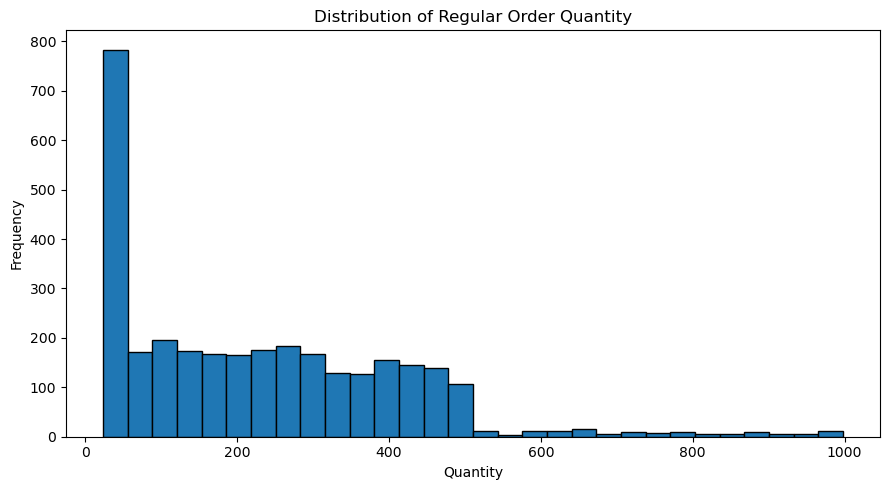

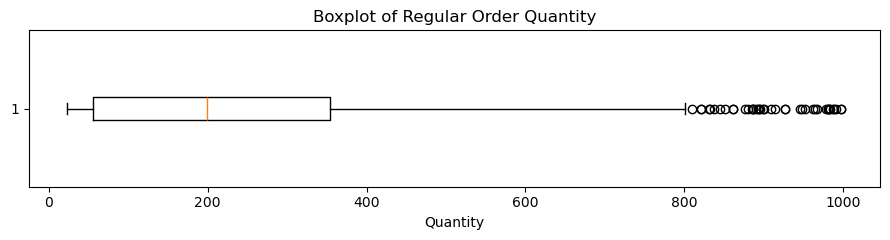


7. UNIQUE VALUE COUNTS
--------------------------------------------------------------------------------
         Variable  Unique_Count  Unique_Percent
 Is_Regular_Order             1            0.03
        Line Type             1            0.03
     Sales_Regime             2            0.06
 Outlier_IQR_Flag             2            0.06
     Market_Group             2            0.06
    Export Market             2            0.06
     Channel Type             3            0.10
             Year             3            0.10
     Product Code             4            0.13
     Product Name             4            0.13
          Quarter             4            0.13
 Unit Price (LKR)             6            0.19
      Day_of_Week             7            0.22
            Month            12            0.39
     Month_Number            12            0.39
       Year_Month            21            0.67
            Buyer            49            1.57
       Time_Trend           474

In [1]:
# ============================================================
# TASK 5A – INITIAL MODELLING DATASET AUDIT
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load the cleaned Regular Orders dataset
# ------------------------------------------------------------

# Expected location when this notebook is stored in:
# 05_Analysis/Task_5/Task5_Predictive_Modelling.ipynb
DATA_PATH = Path("../../04_Cleaned_Data/Fragceylon_Regular_Orders.xlsx")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}\n"
        "Please update DATA_PATH if your Jupyter working directory is different."
    )

df = pd.read_excel(DATA_PATH)

# Standardize Date as datetime for auditing
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("=" * 80)
print("TASK 5A – MODELLING DATASET AUDIT")
print("=" * 80)

# ------------------------------------------------------------
# 2. Dataset shape and variables
# ------------------------------------------------------------

print("\n1. DATASET SHAPE")
print("-" * 80)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

print("\n2. COLUMN NAMES")
print("-" * 80)
for i, col in enumerate(df.columns, start=1):
    print(f"{i:>2}. {col}")

# ------------------------------------------------------------
# 3. Data types
# ------------------------------------------------------------

print("\n3. DATA TYPES")
print("-" * 80)

dtype_table = pd.DataFrame({
    "Variable": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Non_Null_Count": df.notna().sum().values,
    "Unique_Values": df.nunique(dropna=False).values
})

print(dtype_table.to_string(index=False))

# ------------------------------------------------------------
# 4. Missing values
# ------------------------------------------------------------

print("\n4. MISSING VALUES")
print("-" * 80)

missing_table = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": (df.isna().mean() * 100).round(2)
})

print(missing_table.to_string())

print(f"\nTotal missing cells: {df.isna().sum().sum():,}")

# ------------------------------------------------------------
# 5. Exact duplicate rows
# ------------------------------------------------------------

print("\n5. EXACT DUPLICATE ROWS")
print("-" * 80)

duplicate_count = int(df.duplicated().sum())

print(f"Exact duplicate rows: {duplicate_count:,}")

# ------------------------------------------------------------
# 6. Target variable audit
# ------------------------------------------------------------

TARGET = "Quantity"

if TARGET not in df.columns:
    raise KeyError(f"Required target variable '{TARGET}' was not found.")

print("\n6. TARGET VARIABLE – QUANTITY")
print("-" * 80)

quantity_summary = df[TARGET].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

print(quantity_summary)

print(f"\nSkewness: {df[TARGET].skew():.4f}")
print(f"Zero quantities: {(df[TARGET] == 0).sum():,}")
print(f"Negative quantities: {(df[TARGET] < 0).sum():,}")

# IQR information — audit only; observations are NOT removed
q1 = df[TARGET].quantile(0.25)
q3 = df[TARGET].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

iqr_flag_count = (
    (df[TARGET] < lower_bound) |
    (df[TARGET] > upper_bound)
).sum()

print("\nIQR audit:")
print(f"Q1               : {q1:.2f}")
print(f"Q3               : {q3:.2f}")
print(f"IQR              : {iqr:.2f}")
print(f"Lower IQR bound  : {lower_bound:.2f}")
print(f"Upper IQR bound  : {upper_bound:.2f}")
print(f"IQR-flagged rows : {iqr_flag_count:,}")

# ------------------------------------------------------------
# 7. Target distribution plots
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))
plt.hist(df[TARGET].dropna(), bins=30, edgecolor="black")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Regular Order Quantity")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 2.5))
plt.boxplot(df[TARGET].dropna(), vert=False)
plt.xlabel("Quantity")
plt.title("Boxplot of Regular Order Quantity")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Number of unique values in every variable
# ------------------------------------------------------------

print("\n7. UNIQUE VALUE COUNTS")
print("-" * 80)

unique_table = pd.DataFrame({
    "Variable": df.columns,
    "Unique_Count": [df[col].nunique(dropna=False) for col in df.columns],
    "Unique_Percent": [
        round(df[col].nunique(dropna=False) / len(df) * 100, 2)
        for col in df.columns
    ]
}).sort_values("Unique_Count")

print(unique_table.to_string(index=False))

# ------------------------------------------------------------
# 9. Category distributions
# ------------------------------------------------------------

important_categories = [
    "Product Name",
    "Product Code",
    "Channel Type",
    "Buyer",
    "Line Type",
    "Export Market",
    "Year",
    "Month",
    "Month_Number",
    "Quarter",
    "Day_of_Week",
    "Year_Month",
    "Sales_Regime",
    "Market_Group",
    "Is_Regular_Order"
]

print("\n8. CATEGORY FREQUENCIES")
print("-" * 80)

for col in important_categories:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False).to_string())

# ------------------------------------------------------------
# 10. Constant columns
# ------------------------------------------------------------

constant_columns = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]

print("\n9. CONSTANT COLUMNS")
print("-" * 80)

if constant_columns:
    for col in constant_columns:
        print(
            f"{col}: "
            f"{df[col].iloc[0] if len(df) > 0 else 'No observations'}"
        )
else:
    print("No constant columns detected.")

# ------------------------------------------------------------
# 11. Identifier-like variables
# ------------------------------------------------------------

print("\n10. IDENTIFIER-LIKE VARIABLES")
print("-" * 80)

for col in df.columns:
    unique_ratio = df[col].nunique(dropna=False) / len(df)

    if unique_ratio >= 0.95:
        print(
            f"{col:<25} "
            f"unique={df[col].nunique(dropna=False):,} "
            f"({unique_ratio * 100:.2f}% of rows)"
        )

# ------------------------------------------------------------
# 12. Known leakage / modelling-risk variables
# ------------------------------------------------------------

print("\n11. KNOWN LEAKAGE / MODELLING-RISK VARIABLES")
print("-" * 80)

risk_variables = {
    "Total Value (LKR)":
        "Target leakage: Total Value is calculated using Quantity.",

    "Outlier_IQR_Flag":
        "Target leakage: the flag was derived directly from Quantity.",

    "Order ID":
        "Identifier rather than a substantive predictive characteristic.",

    "Is_Regular_Order":
        "Expected to be constant because this dataset contains Regular Orders only.",

    "Line Type":
        "Expected to be constant because this dataset contains Regular Orders only.",

    "Unit Price (LKR)":
        "Timing/endogeneity risk: price may be determined alongside or after order quantity."
}

for variable, reason in risk_variables.items():
    status = "PRESENT" if variable in df.columns else "NOT PRESENT"
    print(f"{variable:<25} [{status}]")
    print(f"    {reason}")

# ------------------------------------------------------------
# 13. Redundancy checks
# ------------------------------------------------------------

print("\n12. REDUNDANCY CHECKS")
print("-" * 80)

# Product Name vs Product Code
if {"Product Name", "Product Code"}.issubset(df.columns):
    product_mapping = (
        df.groupby("Product Name")["Product Code"]
          .nunique()
          .rename("Number_of_Product_Codes")
    )

    print("\nProduct Name -> Product Code mapping:")
    print(product_mapping.to_string())

    print("\nProduct Name × Product Code cross-tabulation:")
    print(
        pd.crosstab(
            df["Product Name"],
            df["Product Code"]
        ).to_string()
    )

# Export Market vs Market Group
if {"Export Market", "Market_Group"}.issubset(df.columns):
    print("\nExport Market × Market_Group:")
    print(
        pd.crosstab(
            df["Export Market"],
            df["Market_Group"],
            dropna=False
        ).to_string()
    )

# ------------------------------------------------------------
# 14. Date/time variable audit
# ------------------------------------------------------------

time_variables = [
    "Date",
    "Year",
    "Month",
    "Month_Number",
    "Quarter",
    "Day_of_Week",
    "Year_Month",
    "Time_Trend",
    "Sales_Regime"
]

present_time_variables = [
    col for col in time_variables
    if col in df.columns
]

print("\n13. DATE / TIME VARIABLES")
print("-" * 80)
print("Present:", present_time_variables)

if "Date" in df.columns:
    print(f"Minimum date: {df['Date'].min()}")
    print(f"Maximum date: {df['Date'].max()}")
    print(f"Unique dates: {df['Date'].nunique():,}")

# ------------------------------------------------------------
# 15. Structural confounding checks
# ------------------------------------------------------------

print("\n14. STRUCTURAL CONFOUNDING CHECKS")
print("-" * 80)

if {"Sales_Regime", "Channel Type"}.issubset(df.columns):
    print("\nSales_Regime × Channel Type:")
    print(
        pd.crosstab(
            df["Sales_Regime"],
            df["Channel Type"],
            margins=True
        ).to_string()
    )

if {"Export Market", "Channel Type"}.issubset(df.columns):
    print("\nExport Market × Channel Type:")
    print(
        pd.crosstab(
            df["Export Market"],
            df["Channel Type"],
            margins=True
        ).to_string()
    )

if {"Export Market", "Sales_Regime"}.issubset(df.columns):
    print("\nExport Market × Sales_Regime:")
    print(
        pd.crosstab(
            df["Export Market"],
            df["Sales_Regime"],
            margins=True
        ).to_string()
    )

if {"Export Market", "Buyer"}.issubset(df.columns):
    japan_rows = df[df["Export Market"].astype(str).str.strip().eq("Japan")]

    print("\nJapan-labelled observations:")
    print(f"Rows: {len(japan_rows):,}")
    print(f"Unique buyers: {japan_rows['Buyer'].nunique():,}")

    if len(japan_rows) > 0:
        print("\nBuyer counts among Japan-labelled observations:")
        print(japan_rows["Buyer"].value_counts().to_string())

# ------------------------------------------------------------
# 16. Preliminary candidate pool for later review
# ------------------------------------------------------------

automatic_exclusions = {
    TARGET,
    "Order ID",
    "Total Value (LKR)",
    "Outlier_IQR_Flag",
    "Is_Regular_Order",
    "Line Type"
}

preliminary_candidate_pool = [
    col for col in df.columns
    if col not in automatic_exclusions
]

print("\n15. PRELIMINARY CANDIDATE POOL")
print("-" * 80)

print(
    "These variables are NOT yet approved for modelling.\n"
    "They will be individually assessed for leakage, redundancy,\n"
    "prediction-time availability, confounding, and generalizability."
)

for col in preliminary_candidate_pool:
    print(f"- {col}")

print("\n" + "=" * 80)
print("AUDIT COMPLETE — NO PREDICTIVE MODEL HAS BEEN FITTED")
print("=" * 80)

### 5A.1 Predictor Audit and Leakage Assessment

Following the initial dataset audit, each available variable was evaluated before predictive modelling. The assessment considered the statistical role of the variable, whether the information would reasonably be available at prediction time, the possibility of target leakage, redundancy with other variables, structural confounding, and likely generalizability.

Variables derived directly from the response variable were excluded to prevent target leakage. Identifier and constant variables were also excluded because they do not provide meaningful predictive information. Where multiple variables represented the same underlying information, only one interpretable representation was retained.

Special consideration was given to **Channel Type**, **Sales Regime**, **Buyer**, and **Export Market**. Channel Type and Sales Regime reflect the April 2025 restructuring and are structurally confounded, so they should not automatically be included together. Buyer identity may improve prediction for previously observed buyers but could reduce generalizability to new customers. Export Market is potentially known at prediction time, but all Japan-labelled transactions are concentrated within one buyer and the post-April Main Dealer structure; consequently, any estimated market association must be interpreted cautiously.

Calendar information was also simplified to avoid including multiple overlapping representations of time. The current predictor decisions remain provisional until the prediction scenario and chronological train-test strategy are finalized.

In [2]:
# ============================================================
# TASK 5A – PREDICTOR DECISION TABLE
# ============================================================

predictor_audit = pd.DataFrame([
    {
        "Variable": "Quantity",
        "Data_Type": str(df["Quantity"].dtype),
        "Role": "Response variable",
        "Decision": "TARGET",
        "Reason": "Primary outcome representing Regular Order demand.",
        "Leakage_Risk": "N/A",
        "Redundancy_Confounding": "N/A",
        "Available_at_Prediction_Time": "No - this is what is being predicted"
    },

    {
        "Variable": "Order ID",
        "Data_Type": str(df["Order ID"].dtype),
        "Role": "Identifier",
        "Decision": "EXCLUDE",
        "Reason": "Unique transaction identifier with no substantive predictive meaning.",
        "Leakage_Risk": "Low",
        "Redundancy_Confounding": "100% unique; risk of memorization",
        "Available_at_Prediction_Time": "Possibly, but not substantively useful"
    },

    {
        "Variable": "Date",
        "Data_Type": str(df["Date"].dtype),
        "Role": "Raw time variable",
        "Decision": "EXCLUDE DIRECTLY",
        "Reason": "Use selected derived calendar/trend variables instead of raw date.",
        "Leakage_Risk": "Low if historical split is respected",
        "Redundancy_Confounding": "Overlaps with Year, Month, Year_Month and Time_Trend",
        "Available_at_Prediction_Time": "Yes"
    },

    {
        "Variable": "Product Name",
        "Data_Type": str(df["Product Name"].dtype),
        "Role": "Categorical predictor",
        "Decision": "PRIMARY CANDIDATE",
        "Reason": "Product identity is known when an order is planned and is directly interpretable.",
        "Leakage_Risk": "Low",
        "Redundancy_Confounding": "Equivalent product information to Product Code",
        "Available_at_Prediction_Time": "Yes"
    },

    {
        "Variable": "Product Code",
        "Data_Type": str(df["Product Code"].dtype),
        "Role": "Categorical product identifier",
        "Decision": "EXCLUDE",
        "Reason": "Contains the same product information as Product Name; Product Name is more interpretable.",
        "Leakage_Risk": "Low",
        "Redundancy_Confounding": "Redundant with Product Name",
        "Available_at_Prediction_Time": "Yes"
    },

    {
        "Variable": "Channel Type",
        "Data_Type": str(df["Channel Type"].dtype),
        "Role": "Categorical business-structure predictor",
        "Decision": "CONDITIONAL",
        "Reason": "Potentially predictive but structurally linked to the April 2025 business change.",
        "Leakage_Risk": "Low",
        "Redundancy_Confounding": "Strong/perfect structural relationship with Sales_Regime",
        "Available_at_Prediction_Time": "Likely yes"
    },

    {
        "Variable": "Buyer",
        "Data_Type": str(df["Buyer"].dtype),
        "Role": "High-cardinality categorical predictor",
        "Decision": "EXCLUDE FROM PRIMARY; OPTIONAL SECONDARY",
        "Reason": "Could improve prediction for known buyers but risks memorizing buyer-specific historical behaviour.",
        "Leakage_Risk": "Low if encoded within training pipeline",
        "Redundancy_Confounding": "Buyer is related to channel and market structure",
        "Available_at_Prediction_Time": "Yes for known buyers; problematic for unseen buyers"
    },

    {
        "Variable": "Line Type",
        "Data_Type": str(df["Line Type"].dtype),
        "Role": "Constant variable",
        "Decision": "EXCLUDE",
        "Reason": "All observations are Regular Orders.",
        "Leakage_Risk": "Low",
        "Redundancy_Confounding": "Constant",
        "Available_at_Prediction_Time": "Yes"
    },

    {
        "Variable": "Unit Price (LKR)",
        "Data_Type": str(df["Unit Price (LKR)"].dtype),
        "Role": "Numeric commercial variable",
        "Decision": "EXCLUDE FROM PRIMARY; SUPPLEMENTARY ONLY",
        "Reason": "Price may be determined partly by quantity, channel, discount rules or order conditions.",
        "Leakage_Risk": "Potential timing/endogeneity risk",
        "Redundancy_Confounding": "Related to business rules and possibly Quantity",
        "Available_at_Prediction_Time": "Uncertain"
    },

    {
        "Variable": "Total Value (LKR)",
        "Data_Type": str(df["Total Value (LKR)"].dtype),
        "Role": "Derived transaction value",
        "Decision": "EXCLUDE",
        "Reason": "Total Value is calculated using Quantity and would create target leakage.",
        "Leakage_Risk": "VERY HIGH",
        "Redundancy_Confounding": "Directly contains target information",
        "Available_at_Prediction_Time": "Not independently of Quantity"
    },

    {
        "Variable": "Export Market",
        "Data_Type": str(df["Export Market"].dtype),
        "Role": "Categorical market predictor",
        "Decision": "PRIMARY CANDIDATE",
        "Reason": "Market is potentially known before order fulfilment and may contain useful predictive information.",
        "Leakage_Risk": "Low",
        "Redundancy_Confounding": "Japan observations are concentrated in one buyer, Main Dealer and post-April period",
        "Available_at_Prediction_Time": "Yes"
    },

    {
        "Variable": "Outlier_IQR_Flag",
        "Data_Type": str(df["Outlier_IQR_Flag"].dtype),
        "Role": "Target-derived diagnostic flag",
        "Decision": "EXCLUDE",
        "Reason": "Flag was created directly from Quantity.",
        "Leakage_Risk": "VERY HIGH",
        "Redundancy_Confounding": "Derived from response variable",
        "Available_at_Prediction_Time": "No"
    },

    {
        "Variable": "Year",
        "Data_Type": str(df["Year"].dtype),
        "Role": "Derived time variable",
        "Decision": "EXCLUDE FROM PRIMARY",
        "Reason": "Time_Trend provides a more continuous representation of progression through time.",
        "Leakage_Risk": "Low",
        "Redundancy_Confounding": "Overlaps with Date, Year_Month and Time_Trend",
        "Available_at_Prediction_Time": "Yes"
    },

    {
        "Variable": "Month",
        "Data_Type": str(df["Month"].dtype),
        "Role": "Categorical calendar predictor",
        "Decision": "PRIMARY CANDIDATE",
        "Reason": "Allows possible non-linear calendar-month differences without assuming a numeric month effect.",
        "Leakage_Risk": "Low",
        "Redundancy_Confounding": "Do not simultaneously use Month_Number and Quarter without justification",
        "Available_at_Prediction_Time": "Yes"
    },

    {
        "Variable": "Month_Number",
        "Data_Type": str(df["Month_Number"].dtype),
        "Role": "Numeric calendar representation",
        "Decision": "EXCLUDE",
        "Reason": "Redundant with Month and would incorrectly imply a simple linear January-to-December relationship if used numerically.",
        "Leakage_Risk": "Low",
        "Redundancy_Confounding": "Equivalent calendar information to Month",
        "Available_at_Prediction_Time": "Yes"
    },

    {
        "Variable": "Quarter",
        "Data_Type": str(df["Quarter"].dtype),
        "Role": "Categorical calendar predictor",
        "Decision": "EXCLUDE FROM PRIMARY",
        "Reason": "Month provides more detailed calendar information.",
        "Leakage_Risk": "Low",
        "Redundancy_Confounding": "Derived directly from Month",
        "Available_at_Prediction_Time": "Yes"
    },

    {
        "Variable": "Day_of_Week",
        "Data_Type": str(df["Day_of_Week"].dtype),
        "Role": "Categorical calendar predictor",
        "Decision": "PRIMARY CANDIDATE",
        "Reason": "Known in advance and may capture systematic order-size differences across weekdays.",
        "Leakage_Risk": "Low",
        "Redundancy_Confounding": "Limited redundancy with other selected variables",
        "Available_at_Prediction_Time": "Yes"
    },

    {
        "Variable": "Year_Month",
        "Data_Type": str(df["Year_Month"].dtype),
        "Role": "High-detail time category",
        "Decision": "EXCLUDE FROM PRIMARY",
        "Reason": "Would create many period-specific categories and may memorize historical months instead of generalizing.",
        "Leakage_Risk": "Low if split correctly",
        "Redundancy_Confounding": "Overlaps strongly with Date, Year, Month and Time_Trend",
        "Available_at_Prediction_Time": "Yes, but future unseen levels are problematic"
    },

    {
        "Variable": "Time_Trend",
        "Data_Type": str(df["Time_Trend"].dtype),
        "Role": "Numeric temporal predictor",
        "Decision": "PRIMARY CANDIDATE",
        "Reason": "Provides a parsimonious representation of systematic change over historical time.",
        "Leakage_Risk": "Low with chronological splitting",
        "Redundancy_Confounding": "Overlaps with Year and Date; therefore those are not used directly",
        "Available_at_Prediction_Time": "Yes, if constructed consistently"
    },

    {
        "Variable": "Sales_Regime",
        "Data_Type": str(df["Sales_Regime"].dtype),
        "Role": "Structural-change indicator",
        "Decision": "CONDITIONAL",
        "Reason": "Represents the April 2025 business change but is structurally confounded with Channel Type.",
        "Leakage_Risk": "Low",
        "Redundancy_Confounding": "Do not include automatically with Channel Type",
        "Available_at_Prediction_Time": "Yes for the historical/current regime"
    },

    {
        "Variable": "Market_Group",
        "Data_Type": str(df["Market_Group"].dtype),
        "Role": "Categorical market representation",
        "Decision": "EXCLUDE",
        "Reason": "Contains the same market distinction as Export Market.",
        "Leakage_Risk": "Low",
        "Redundancy_Confounding": "Redundant with Export Market",
        "Available_at_Prediction_Time": "Yes"
    },

    {
        "Variable": "Is_Regular_Order",
        "Data_Type": str(df["Is_Regular_Order"].dtype),
        "Role": "Constant indicator",
        "Decision": "EXCLUDE",
        "Reason": "All observations in the modelling dataset are Regular Orders.",
        "Leakage_Risk": "Low",
        "Redundancy_Confounding": "Constant",
        "Available_at_Prediction_Time": "Yes"
    }
])

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", None)

print("=" * 120)
print("TASK 5A – PROFESSIONAL PREDICTOR DECISION TABLE")
print("=" * 120)

display(predictor_audit)

print("\nPRIMARY CANDIDATES CURRENTLY IDENTIFIED")
print("-" * 80)

primary_candidates = predictor_audit.loc[
    predictor_audit["Decision"] == "PRIMARY CANDIDATE",
    "Variable"
].tolist()

for variable in primary_candidates:
    print(f"- {variable}")

print("\nCONDITIONAL VARIABLES REQUIRING TASK 5B DECISION")
print("-" * 80)

conditional_variables = predictor_audit.loc[
    predictor_audit["Decision"] == "CONDITIONAL",
    "Variable"
].tolist()

for variable in conditional_variables:
    print(f"- {variable}")

print("\nNo predictive model has been fitted.")

TASK 5A – PROFESSIONAL PREDICTOR DECISION TABLE


,Variable,Data_Type,Role,Decision,Reason,Leakage_Risk,Redundancy_Confounding,Available_at_Prediction_Time
0,Quantity,int64,Response variable,TARGET,Primary outcome representing Regular Order demand.,N/A,N/A,No - this is what is being predicted
1,Order ID,object,Identifier,EXCLUDE,Unique transaction identifier with no substantive predictive meaning.,Low,100% unique; risk of memorization,"Possibly, but not substantively useful"
2,Date,datetime64[ns],Raw time variable,EXCLUDE DIRECTLY,Use selected derived calendar/trend variables instead of raw date.,Low if historical split is respected,"Overlaps with Year, Month, Year_Month and Time_Trend",Yes
3,Product Name,object,Categorical predictor,PRIMARY CANDIDATE,Product identity is known when an order is planned and is directly interpret...,Low,Equivalent product information to Product Code,Yes
4,Product Code,object,Categorical product identifier,EXCLUDE,Contains the same product information as Product Name; Product Name is more ...,Low,Redundant with Product Name,Yes
5,Channel Type,object,Categorical business-structure predictor,CONDITIONAL,Potentially predictive but structurally linked to the April 2025 business ch...,Low,Strong/perfect structural relationship with Sales_Regime,Likely yes
6,Buyer,object,High-cardinality categorical predictor,EXCLUDE FROM PRIMARY; OPTIONAL SECONDARY,Could improve prediction for known buyers but risks memorizing buyer-specifi...,Low if encoded within training pipeline,Buyer is related to channel and market structure,Yes for known buyers; problematic for unseen buyers
7,Line Type,object,Constant variable,EXCLUDE,All observations are Regular Orders.,Low,Constant,Yes
8,Unit Price (LKR),float64,Numeric commercial variable,EXCLUDE FROM PRIMARY; SUPPLEMENTARY ONLY,"Price may be determined partly by quantity, channel, discount rules or order...",Potential timing/endogeneity risk,Related to business rules and possibly Quantity,Uncertain
9,Total Value (LKR),float64,Derived transaction value,EXCLUDE,Total Value is calculated using Quantity and would create target leakage.,VERY HIGH,Directly contains target information,Not independently of Quantity



PRIMARY CANDIDATES CURRENTLY IDENTIFIED
--------------------------------------------------------------------------------
- Product Name
- Export Market
- Month
- Day_of_Week
- Time_Trend

CONDITIONAL VARIABLES REQUIRING TASK 5B DECISION
--------------------------------------------------------------------------------
- Channel Type
- Sales_Regime

No predictive model has been fitted.


## 5B – Prediction Scenario and Time-Aware Validation Strategy

The primary prediction objective is to estimate **Regular Order Quantity for future transactions under Fragceylon's current business structure**, using information that would reasonably be known before or when an order is planned.

Because the sales process changed substantially around April 2025, observations from the earlier Shop and Small Dealer structure are not treated as fully representative of the organization's current operating environment. The primary predictive analysis therefore focuses on the **post-April-2025 period**, where the Main Dealer structure is consistently observed.

Within this current-regime dataset, **Channel Type** and **Sales Regime** do not provide independent predictive variation because they are constant. They are therefore excluded from the primary model rather than interpreted as separate effects.

The provisional primary predictors are:

- Product Name
- Export Market
- Month
- Day of Week
- Time Trend

Buyer identity is excluded from the primary model to reduce dependence on customer-specific memorization and improve potential generalizability. A buyer-aware specification may later be considered as a secondary analysis.

A **chronological train-test split** is preferred over a random split because the practical objective is prediction of future orders. Earlier observations will therefore be used for model development and the most recent consecutive period will be retained as unseen test data. The exact holdout period will be selected after examining sample size, category coverage, market representation, and target behaviour across several plausible recent-month windows.

All preprocessing and model estimation will subsequently be performed using the training data only to prevent information from the future test period from leaking into model development.

In [3]:
# ============================================================
# TASK 5B – DEFINE CURRENT-REGIME MODELLING POPULATION
#           AND INSPECT CHRONOLOGICAL HOLDOUT OPTIONS
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Construct primary current-regime modelling dataset
# ------------------------------------------------------------

CURRENT_REGIME_START = pd.Timestamp("2025-04-01")

current_df = (
    df.loc[df["Date"] >= CURRENT_REGIME_START]
      .copy()
      .sort_values("Date")
      .reset_index(drop=True)
)

print("=" * 90)
print("TASK 5B – CURRENT-REGIME MODELLING POPULATION")
print("=" * 90)

print(f"\nObservations : {len(current_df):,}")
print(f"Variables    : {current_df.shape[1]}")
print(f"Start date   : {current_df['Date'].min().date()}")
print(f"End date     : {current_df['Date'].max().date()}")

# ------------------------------------------------------------
# 2. Confirm Channel Type and Sales Regime are constant
# ------------------------------------------------------------

print("\n1. STRUCTURAL VARIABLES IN CURRENT REGIME")
print("-" * 90)

for col in ["Channel Type", "Sales_Regime"]:
    print(f"\n{col}:")
    print(current_df[col].value_counts(dropna=False).to_string())
    print(f"Unique values: {current_df[col].nunique(dropna=False)}")

# ------------------------------------------------------------
# 3. Confirm primary predictor coverage
# ------------------------------------------------------------

primary_predictors = [
    "Product Name",
    "Export Market",
    "Month",
    "Day_of_Week",
    "Time_Trend"
]

print("\n2. PRIMARY PREDICTOR COVERAGE")
print("-" * 90)

for col in primary_predictors:
    print(
        f"{col:<20} "
        f"unique={current_df[col].nunique(dropna=False):>3}   "
        f"missing={current_df[col].isna().sum():>3}"
    )

# ------------------------------------------------------------
# 4. Monthly structure of current-regime data
# ------------------------------------------------------------

current_df["Year_Month_Period"] = current_df["Date"].dt.to_period("M")

monthly_audit = (
    current_df
    .groupby("Year_Month_Period", observed=True)
    .agg(
        Orders=("Quantity", "size"),
        Mean_Quantity=("Quantity", "mean"),
        Median_Quantity=("Quantity", "median"),
        SD_Quantity=("Quantity", "std"),
        Min_Quantity=("Quantity", "min"),
        Max_Quantity=("Quantity", "max"),
        Products=("Product Name", "nunique"),
        Markets=("Export Market", "nunique"),
        Buyers=("Buyer", "nunique")
    )
    .reset_index()
)

monthly_audit["Mean_Quantity"] = monthly_audit["Mean_Quantity"].round(2)
monthly_audit["Median_Quantity"] = monthly_audit["Median_Quantity"].round(2)
monthly_audit["SD_Quantity"] = monthly_audit["SD_Quantity"].round(2)

print("\n3. MONTHLY CURRENT-REGIME AUDIT")
print("-" * 90)

print(monthly_audit.to_string(index=False))

# ------------------------------------------------------------
# 5. Candidate chronological holdout windows
# ------------------------------------------------------------

unique_months = sorted(current_df["Year_Month_Period"].unique())

categorical_predictors = [
    "Product Name",
    "Export Market",
    "Month",
    "Day_of_Week"
]

holdout_sizes = [3, 4, 5, 6]

print("\n4. CANDIDATE CHRONOLOGICAL HOLDOUT WINDOWS")
print("=" * 90)

for n_test_months in holdout_sizes:

    if len(unique_months) <= n_test_months:
        continue

    test_months = unique_months[-n_test_months:]

    train_mask = ~current_df["Year_Month_Period"].isin(test_months)
    test_mask = current_df["Year_Month_Period"].isin(test_months)

    train_temp = current_df.loc[train_mask].copy()
    test_temp = current_df.loc[test_mask].copy()

    print("\n" + "=" * 90)
    print(f"LAST {n_test_months} MONTHS AS TEST SET")
    print("=" * 90)

    print(
        f"Training period : "
        f"{train_temp['Date'].min().date()} to "
        f"{train_temp['Date'].max().date()}"
    )

    print(
        f"Testing period  : "
        f"{test_temp['Date'].min().date()} to "
        f"{test_temp['Date'].max().date()}"
    )

    print(f"\nTraining rows   : {len(train_temp):,}")
    print(f"Testing rows    : {len(test_temp):,}")
    print(
        f"Test proportion : "
        f"{len(test_temp) / len(current_df) * 100:.2f}%"
    )

    # --------------------------------------------------------
    # Target distribution comparison
    # --------------------------------------------------------

    print("\nQuantity summary:")

    quantity_comparison = pd.DataFrame({
        "Training": train_temp["Quantity"].describe(),
        "Testing": test_temp["Quantity"].describe()
    }).round(2)

    print(quantity_comparison.to_string())

    # --------------------------------------------------------
    # Category-level coverage
    # --------------------------------------------------------

    print("\nCategory coverage:")

    for col in categorical_predictors:

        train_levels = set(train_temp[col].dropna().unique())
        test_levels = set(test_temp[col].dropna().unique())

        unseen_test_levels = sorted(test_levels - train_levels)

        print(
            f"{col:<20} "
            f"train_levels={len(train_levels):>2}  "
            f"test_levels={len(test_levels):>2}  "
            f"unseen_in_test={unseen_test_levels}"
        )

    # --------------------------------------------------------
    # Product distribution
    # --------------------------------------------------------

    print("\nTest-set product counts:")
    print(
        test_temp["Product Name"]
        .value_counts()
        .to_string()
    )

    # --------------------------------------------------------
    # Market distribution
    # --------------------------------------------------------

    print("\nTest-set market counts:")
    print(
        test_temp["Export Market"]
        .value_counts()
        .to_string()
    )

# ------------------------------------------------------------
# 6. No model fitted
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("HOLDOUT AUDIT COMPLETE — NO PREDICTIVE MODEL HAS BEEN FITTED")
print("=" * 90)

TASK 5B – CURRENT-REGIME MODELLING POPULATION

Observations : 2,014
Variables    : 22
Start date   : 2025-04-01
End date     : 2026-06-30

1. STRUCTURAL VARIABLES IN CURRENT REGIME
------------------------------------------------------------------------------------------

Channel Type:
Channel Type
Main Dealer    2014
Unique values: 1

Sales_Regime:
Sales_Regime
Post-April-2025    2014
Unique values: 1

2. PRIMARY PREDICTOR COVERAGE
------------------------------------------------------------------------------------------
Product Name         unique=  4   missing=  0
Export Market        unique=  2   missing=  0
Month                unique= 12   missing=  0
Day_of_Week          unique=  7   missing=  0
Time_Trend           unique=326   missing=  0

3. MONTHLY CURRENT-REGIME AUDIT
------------------------------------------------------------------------------------------
Year_Month_Period  Orders  Mean_Quantity  Median_Quantity  SD_Quantity  Min_Quantity  Max_Quantity  Products  Markets 

### 5B.1 Final Chronological Train–Test Split

A chronological holdout strategy was selected to reflect the practical objective of predicting future Regular Order quantities. Several recent-period holdout windows were evaluated before model development.

The final test period was defined as **1 April 2026 to 30 June 2026**, while observations from **1 April 2025 to 31 March 2026** were retained for model development. This produced:

- **Training set:** 1,599 observations
- **Test set:** 415 observations
- **Test proportion:** approximately 20.6%

This split was preferred because the training period contains all twelve calendar months and therefore provides historical observations for every level of the Month predictor. It also contains all four products, both market categories, and all seven days of the week. No categorical level appearing in the test set is absent from the training data.

Longer holdout windows were not selected because they caused some calendar-month categories in the test period to be absent from training. The three-month holdout therefore provides a stronger balance between chronological validity, category coverage, training sample size, and final test-set size.

The test period is treated as an **unseen final evaluation sample**. Model development, preprocessing decisions, regularization tuning, and any internal model comparisons will be performed using the training data only. The final test set will not be used to optimize model specifications.

The provisional primary predictors are:

- Product Name
- Export Market
- Month
- Day of Week
- Time Trend

The response variable is **Quantity**.

Channel Type and Sales Regime are excluded because both are constant within the current post-April-2025 modelling population. Buyer is excluded from the primary specification to reduce dependence on customer-specific memorization.

In [4]:
# ============================================================
# TASK 5B – FINAL CHRONOLOGICAL TRAIN–TEST SPLIT
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Define final prediction variables
# ------------------------------------------------------------

TARGET = "Quantity"

PRIMARY_PREDICTORS = [
    "Product Name",
    "Export Market",
    "Month",
    "Day_of_Week",
    "Time_Trend"
]

TEST_START_DATE = pd.Timestamp("2026-04-01")

# ------------------------------------------------------------
# 2. Create final chronological training and test datasets
# ------------------------------------------------------------

train_df = (
    current_df.loc[current_df["Date"] < TEST_START_DATE]
    .copy()
    .sort_values("Date")
    .reset_index(drop=True)
)

test_df = (
    current_df.loc[current_df["Date"] >= TEST_START_DATE]
    .copy()
    .sort_values("Date")
    .reset_index(drop=True)
)

X_train = train_df[PRIMARY_PREDICTORS].copy()
y_train = train_df[TARGET].copy()

X_test = test_df[PRIMARY_PREDICTORS].copy()
y_test = test_df[TARGET].copy()

# ------------------------------------------------------------
# 3. Basic split verification
# ------------------------------------------------------------

print("=" * 90)
print("TASK 5B – FINAL CHRONOLOGICAL TRAIN–TEST SPLIT")
print("=" * 90)

print("\nTRAINING SET")
print("-" * 90)
print(f"Rows          : {len(train_df):,}")
print(f"Start date    : {train_df['Date'].min().date()}")
print(f"End date      : {train_df['Date'].max().date()}")
print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")

print("\nTEST SET")
print("-" * 90)
print(f"Rows         : {len(test_df):,}")
print(f"Start date   : {test_df['Date'].min().date()}")
print(f"End date     : {test_df['Date'].max().date()}")
print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")

print(
    f"\nTest proportion: "
    f"{len(test_df) / len(current_df) * 100:.2f}%"
)

# ------------------------------------------------------------
# 4. Verify strict chronological separation
# ------------------------------------------------------------

print("\n1. CHRONOLOGICAL SEPARATION")
print("-" * 90)

train_last_date = train_df["Date"].max()
test_first_date = test_df["Date"].min()

print(f"Latest training date : {train_last_date.date()}")
print(f"Earliest test date   : {test_first_date.date()}")
print(f"Strict separation    : {train_last_date < test_first_date}")

# ------------------------------------------------------------
# 5. Verify predictor and target missing values
# ------------------------------------------------------------

print("\n2. MISSING-VALUE CHECK")
print("-" * 90)

print("Training predictors:")
print(X_train.isna().sum().to_string())

print("\nTest predictors:")
print(X_test.isna().sum().to_string())

print(f"\nMissing y_train values: {y_train.isna().sum()}")
print(f"Missing y_test values : {y_test.isna().sum()}")

# ------------------------------------------------------------
# 6. Verify categorical coverage
# ------------------------------------------------------------

categorical_predictors = [
    "Product Name",
    "Export Market",
    "Month",
    "Day_of_Week"
]

print("\n3. CATEGORICAL COVERAGE")
print("-" * 90)

for col in categorical_predictors:

    train_levels = sorted(X_train[col].dropna().unique())
    test_levels = sorted(X_test[col].dropna().unique())

    unseen_test = sorted(
        set(test_levels) - set(train_levels)
    )

    print(f"\n{col}")
    print(f"Training levels : {train_levels}")
    print(f"Test levels     : {test_levels}")
    print(f"Unseen in test  : {unseen_test}")

# ------------------------------------------------------------
# 7. Verify Time_Trend separation
# ------------------------------------------------------------

print("\n4. TIME TREND RANGE")
print("-" * 90)

print(
    f"Training Time_Trend: "
    f"{X_train['Time_Trend'].min()} to "
    f"{X_train['Time_Trend'].max()}"
)

print(
    f"Testing Time_Trend : "
    f"{X_test['Time_Trend'].min()} to "
    f"{X_test['Time_Trend'].max()}"
)

# ------------------------------------------------------------
# 8. Target summary — descriptive verification only
# ------------------------------------------------------------

print("\n5. TARGET SUMMARY")
print("-" * 90)

target_summary = pd.DataFrame({
    "Training": y_train.describe(),
    "Testing": y_test.describe()
}).round(2)

print(target_summary.to_string())

# ------------------------------------------------------------
# 9. Final predictor specification
# ------------------------------------------------------------

print("\n6. FINAL PRIMARY PREDICTOR SPECIFICATION")
print("-" * 90)

print(f"Response variable: {TARGET}")

print("\nPredictors:")
for predictor in PRIMARY_PREDICTORS:
    print(f"- {predictor}")

print("\nExplicitly excluded from primary model:")
print("- Order ID")
print("- Product Code")
print("- Buyer")
print("- Line Type")
print("- Unit Price (LKR)")
print("- Total Value (LKR)")
print("- Outlier_IQR_Flag")
print("- Year")
print("- Month_Number")
print("- Quarter")
print("- Year_Month")
print("- Channel Type")
print("- Sales_Regime")
print("- Market_Group")
print("- Is_Regular_Order")
print("- Raw Date")

print("\n" + "=" * 90)
print("FINAL SPLIT LOCKED — NO PREDICTIVE MODEL HAS BEEN FITTED")
print("=" * 90)

TASK 5B – FINAL CHRONOLOGICAL TRAIN–TEST SPLIT

TRAINING SET
------------------------------------------------------------------------------------------
Rows          : 1,599
Start date    : 2025-04-01
End date      : 2026-03-31
X_train shape : (1599, 5)
y_train shape : (1599,)

TEST SET
------------------------------------------------------------------------------------------
Rows         : 415
Start date   : 2026-04-01
End date     : 2026-06-30
X_test shape : (415, 5)
y_test shape : (415,)

Test proportion: 20.61%

1. CHRONOLOGICAL SEPARATION
------------------------------------------------------------------------------------------
Latest training date : 2026-03-31
Earliest test date   : 2026-04-01
Strict separation    : True

2. MISSING-VALUE CHECK
------------------------------------------------------------------------------------------
Training predictors:
Product Name     0
Export Market    0
Month            0
Day_of_Week      0
Time_Trend       0

Test predictors:
Product Name  

## 5C – Baseline Predictive Model

Before fitting more complex statistical models, a simple benchmark was established using the **mean Quantity from the training dataset**.

The baseline model predicts the same quantity for every observation:

\[
\hat{Y}_i = \bar{Y}_{train}
\]

where \(\bar{Y}_{train}\) is the mean Regular Order Quantity calculated using the training data only.

This benchmark provides a minimum predictive standard against which subsequent models can be evaluated. A more complex model should demonstrate meaningful improvement over this simple approach to justify its additional statistical and operational complexity.

Model performance is evaluated using:

- **Mean Absolute Error (MAE):** the average absolute difference between observed and predicted quantities.
- **Root Mean Squared Error (RMSE):** the square root of the average squared prediction error, which gives greater weight to large prediction errors.
- **R²:** the proportion of variation explained relative to a constant prediction benchmark.

Both training and unseen test-set performance are reported. The test set remains chronologically later than the training data and is not used to estimate the baseline prediction.

In [6]:
# ============================================================
# TASK 5C – BASELINE MODEL
# Training-set Mean Predictor
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# 1. Estimate baseline value using TRAINING DATA ONLY
# ------------------------------------------------------------

baseline_value = y_train.mean()

print("=" * 90)
print("TASK 5C – BASELINE MODEL")
print("=" * 90)

print(f"\nTraining-set mean Quantity: {baseline_value:.4f}")

# ------------------------------------------------------------
# 2. Generate constant predictions
# ------------------------------------------------------------

baseline_train_pred = np.full(
    shape=len(y_train),
    fill_value=baseline_value,
    dtype=float
)

baseline_test_pred = np.full(
    shape=len(y_test),
    fill_value=baseline_value,
    dtype=float
)

# ------------------------------------------------------------
# 3. Reusable evaluation function
# ------------------------------------------------------------

def regression_metrics(y_true, y_pred):
    """
    Calculate regression performance metrics.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


# ------------------------------------------------------------
# 4. Calculate training and test metrics
# ------------------------------------------------------------

baseline_train_metrics = regression_metrics(
    y_train,
    baseline_train_pred
)

baseline_test_metrics = regression_metrics(
    y_test,
    baseline_test_pred
)

# ------------------------------------------------------------
# 5. Display performance
# ------------------------------------------------------------

baseline_performance = pd.DataFrame({
    "Training": baseline_train_metrics,
    "Testing": baseline_test_metrics
}).T

print("\n1. BASELINE PERFORMANCE")
print("-" * 90)

print(
    baseline_performance
    .round(4)
    .to_string()
)

# ------------------------------------------------------------
# 6. Additional descriptive comparison
# ------------------------------------------------------------

print("\n2. ACTUAL VS BASELINE QUANTITY LEVEL")
print("-" * 90)

print(f"Baseline prediction             : {baseline_value:.2f}")
print(f"Actual training mean            : {y_train.mean():.2f}")
print(f"Actual test mean                : {y_test.mean():.2f}")
print(f"Actual test median              : {y_test.median():.2f}")

print(
    f"Test mean - baseline prediction : "
    f"{y_test.mean() - baseline_value:.2f}"
)

# ------------------------------------------------------------
# 7. Store baseline result for later model comparison
# ------------------------------------------------------------

model_results = pd.DataFrame([
    {
        "Model": "Training Mean Baseline",
        "Train_MAE": baseline_train_metrics["MAE"],
        "Train_RMSE": baseline_train_metrics["RMSE"],
        "Train_R2": baseline_train_metrics["R2"],
        "Test_MAE": baseline_test_metrics["MAE"],
        "Test_RMSE": baseline_test_metrics["RMSE"],
        "Test_R2": baseline_test_metrics["R2"]
    }
])

print("\n3. MODEL COMPARISON TABLE INITIALIZED")
print("-" * 90)

print(
    model_results
    .round(4)
    .to_string(index=False)
)

print("\n" + "=" * 90)
print("BASELINE MODEL COMPLETE")
print("=" * 90)

TASK 5C – BASELINE MODEL

Training-set mean Quantity: 306.5503

1. BASELINE PERFORMANCE
------------------------------------------------------------------------------------------
               MAE      RMSE     R2
Training  133.9660  170.5427  0.000
Testing   137.0608  178.3421 -0.005

2. ACTUAL VS BASELINE QUANTITY LEVEL
------------------------------------------------------------------------------------------
Baseline prediction             : 306.55
Actual training mean            : 306.55
Actual test mean                : 319.09
Actual test median              : 311.00
Test mean - baseline prediction : 12.54

3. MODEL COMPARISON TABLE INITIALIZED
------------------------------------------------------------------------------------------
                 Model  Train_MAE  Train_RMSE  Train_R2  Test_MAE  Test_RMSE  Test_R2
Training Mean Baseline    133.966    170.5427       0.0  137.0608   178.3421   -0.005

BASELINE MODEL COMPLETE


## 5D – Multiple Linear Regression

A Multiple Linear Regression (MLR) model was developed as the first interpretable predictive model for Regular Order Quantity. The model uses the finalized predictors identified during the predictor-audit stage:

- Product Name
- Export Market
- Month
- Day of Week
- Time Trend

Categorical predictors are represented using treatment (dummy) coding. For interpretability, the reference categories are defined as:

- **Product Name:** Dark Matrix
- **Export Market:** Local
- **Month:** April
- **Day of Week:** Monday

Time Trend is centered using the mean calculated from the training data only. This improves interpretation of the intercept while preserving the same underlying temporal relationship.

The fitted model can be represented conceptually as:

\[
Quantity_i =
\beta_0 +
\beta_{Product} +
\beta_{Market} +
\beta_{Month} +
\beta_{Day} +
\beta_1(TimeTrendCentered_i) +
\epsilon_i
\]

Each categorical coefficient represents the estimated difference in Quantity relative to its reference category, conditional on the other included predictors. The Time Trend coefficient represents the estimated change in expected order quantity for a one-unit increase in the historical time index.

The model is estimated using the training period only. Predictive performance is subsequently evaluated on the chronologically later test dataset using MAE, RMSE, and R².

Because the available data are observational, regression coefficients are interpreted as **statistical associations rather than causal effects**. Regression assumptions and influential observations are assessed separately in the diagnostic stage.

In [7]:
# ============================================================
# TASK 5D – MULTIPLE LINEAR REGRESSION
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ------------------------------------------------------------
# 1. Prepare training and test modelling datasets
# ------------------------------------------------------------

mlr_train = train_df[
    [
        "Quantity",
        "Product Name",
        "Export Market",
        "Month",
        "Day_of_Week",
        "Time_Trend"
    ]
].copy()

mlr_test = test_df[
    [
        "Quantity",
        "Product Name",
        "Export Market",
        "Month",
        "Day_of_Week",
        "Time_Trend"
    ]
].copy()

# ------------------------------------------------------------
# 2. Center Time_Trend using TRAINING DATA ONLY
# ------------------------------------------------------------

time_trend_mean = mlr_train["Time_Trend"].mean()

mlr_train["Time_Trend_Centered"] = (
    mlr_train["Time_Trend"] - time_trend_mean
)

mlr_test["Time_Trend_Centered"] = (
    mlr_test["Time_Trend"] - time_trend_mean
)

print("=" * 100)
print("TASK 5D – MULTIPLE LINEAR REGRESSION")
print("=" * 100)

print(f"\nTraining Time_Trend mean used for centering: {time_trend_mean:.4f}")

print(
    f"Centered training range: "
    f"{mlr_train['Time_Trend_Centered'].min():.2f} to "
    f"{mlr_train['Time_Trend_Centered'].max():.2f}"
)

print(
    f"Centered testing range : "
    f"{mlr_test['Time_Trend_Centered'].min():.2f} to "
    f"{mlr_test['Time_Trend_Centered'].max():.2f}"
)

# ------------------------------------------------------------
# 3. Specify regression formula with explicit references
# ------------------------------------------------------------

mlr_formula = """
Q("Quantity")
~
C(Q("Product Name"), Treatment(reference="Dark Matrix"))
+
C(Q("Export Market"), Treatment(reference="Local"))
+
C(Q("Month"), Treatment(reference="April"))
+
C(Q("Day_of_Week"), Treatment(reference="Monday"))
+
Time_Trend_Centered
"""

# ------------------------------------------------------------
# 4. Fit OLS model using TRAINING DATA ONLY
# ------------------------------------------------------------

mlr_model = smf.ols(
    formula=mlr_formula,
    data=mlr_train
).fit()

# ------------------------------------------------------------
# 5. Display overall model statistics
# ------------------------------------------------------------

print("\n1. OVERALL MODEL FIT – TRAINING DATA")
print("-" * 100)

print(f"Number of observations : {int(mlr_model.nobs):,}")
print(f"R-squared              : {mlr_model.rsquared:.6f}")
print(f"Adjusted R-squared     : {mlr_model.rsquared_adj:.6f}")
print(f"F-statistic            : {mlr_model.fvalue:.4f}")
print(f"Model F-test p-value   : {mlr_model.f_pvalue:.6g}")
print(f"AIC                    : {mlr_model.aic:.2f}")
print(f"BIC                    : {mlr_model.bic:.2f}")

# ------------------------------------------------------------
# 6. Create coefficient table with confidence intervals
# ------------------------------------------------------------

conf_int = mlr_model.conf_int()

coefficient_table = pd.DataFrame({
    "Coefficient": mlr_model.params,
    "Std_Error": mlr_model.bse,
    "t_value": mlr_model.tvalues,
    "p_value": mlr_model.pvalues,
    "CI_2.5%": conf_int[0],
    "CI_97.5%": conf_int[1]
})

print("\n2. REGRESSION COEFFICIENTS")
print("-" * 100)

print(
    coefficient_table
    .round({
        "Coefficient": 4,
        "Std_Error": 4,
        "t_value": 4,
        "p_value": 6,
        "CI_2.5%": 4,
        "CI_97.5%": 4
    })
    .to_string()
)

# ------------------------------------------------------------
# 7. Generate train and unseen-test predictions
# ------------------------------------------------------------

mlr_train_pred = mlr_model.predict(mlr_train)
mlr_test_pred = mlr_model.predict(mlr_test)

# ------------------------------------------------------------
# 8. Evaluate predictive performance
# ------------------------------------------------------------

mlr_train_metrics = regression_metrics(
    y_train,
    mlr_train_pred
)

mlr_test_metrics = regression_metrics(
    y_test,
    mlr_test_pred
)

mlr_performance = pd.DataFrame({
    "Training": mlr_train_metrics,
    "Testing": mlr_test_metrics
}).T

print("\n3. MULTIPLE LINEAR REGRESSION PERFORMANCE")
print("-" * 100)

print(
    mlr_performance
    .round(4)
    .to_string()
)

# ------------------------------------------------------------
# 9. Compare MLR with baseline
# ------------------------------------------------------------

comparison_baseline_mlr = pd.DataFrame([
    {
        "Model": "Training Mean Baseline",
        "Train_MAE": baseline_train_metrics["MAE"],
        "Train_RMSE": baseline_train_metrics["RMSE"],
        "Train_R2": baseline_train_metrics["R2"],
        "Test_MAE": baseline_test_metrics["MAE"],
        "Test_RMSE": baseline_test_metrics["RMSE"],
        "Test_R2": baseline_test_metrics["R2"]
    },
    {
        "Model": "Multiple Linear Regression",
        "Train_MAE": mlr_train_metrics["MAE"],
        "Train_RMSE": mlr_train_metrics["RMSE"],
        "Train_R2": mlr_train_metrics["R2"],
        "Test_MAE": mlr_test_metrics["MAE"],
        "Test_RMSE": mlr_test_metrics["RMSE"],
        "Test_R2": mlr_test_metrics["R2"]
    }
])

print("\n4. BASELINE VS MULTIPLE LINEAR REGRESSION")
print("-" * 100)

print(
    comparison_baseline_mlr
    .round(4)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 10. Quantify test-set improvement over baseline
# ------------------------------------------------------------

mae_improvement = (
    baseline_test_metrics["MAE"]
    - mlr_test_metrics["MAE"]
)

rmse_improvement = (
    baseline_test_metrics["RMSE"]
    - mlr_test_metrics["RMSE"]
)

mae_improvement_pct = (
    mae_improvement
    / baseline_test_metrics["MAE"]
    * 100
)

rmse_improvement_pct = (
    rmse_improvement
    / baseline_test_metrics["RMSE"]
    * 100
)

print("\n5. TEST-SET IMPROVEMENT OVER BASELINE")
print("-" * 100)

print(
    f"MAE improvement       : "
    f"{mae_improvement:.4f} units "
    f"({mae_improvement_pct:.2f}%)"
)

print(
    f"RMSE improvement      : "
    f"{rmse_improvement:.4f} units "
    f"({rmse_improvement_pct:.2f}%)"
)

print(
    f"Test R² change        : "
    f"{mlr_test_metrics['R2'] - baseline_test_metrics['R2']:.4f}"
)

# ------------------------------------------------------------
# 11. Prediction range check
# ------------------------------------------------------------

print("\n6. PREDICTION RANGE CHECK")
print("-" * 100)

print(
    f"Observed training Quantity : "
    f"{y_train.min():.2f} to {y_train.max():.2f}"
)

print(
    f"Predicted training Quantity: "
    f"{mlr_train_pred.min():.2f} to {mlr_train_pred.max():.2f}"
)

print(
    f"Observed test Quantity     : "
    f"{y_test.min():.2f} to {y_test.max():.2f}"
)

print(
    f"Predicted test Quantity    : "
    f"{mlr_test_pred.min():.2f} to {mlr_test_pred.max():.2f}"
)

print(
    f"Negative test predictions : "
    f"{(mlr_test_pred < 0).sum()}"
)

# ------------------------------------------------------------
# 12. Update model comparison table
# ------------------------------------------------------------

model_results = comparison_baseline_mlr.copy()

print("\n" + "=" * 100)
print("MULTIPLE LINEAR REGRESSION FIT COMPLETE")
print("DIAGNOSTICS HAVE NOT YET BEEN ASSESSED")
print("=" * 100)

TASK 5D – MULTIPLE LINEAR REGRESSION

Training Time_Trend mean used for centering: 372.9669
Centered training range: -207.97 to 156.03
Centered testing range : 157.03 to 247.03

1. OVERALL MODEL FIT – TRAINING DATA
----------------------------------------------------------------------------------------------------
Number of observations : 1,599
R-squared              : 0.326319
Adjusted R-squared     : 0.316915
F-statistic            : 34.6994
Model F-test p-value   : 2.54343e-118
AIC                    : 20386.64
BIC                    : 20510.31

2. REGRESSION COEFFICIENTS
----------------------------------------------------------------------------------------------------
                                                                             Coefficient  Std_Error  t_value   p_value   CI_2.5%  CI_97.5%
Intercept                                                                       271.4198    79.6016   3.4097  0.000667  115.2835  427.5560
C(Q("Product Name"), Treatment(referenc

## 5E – Multiple Linear Regression Diagnostics

Before relying on the Multiple Linear Regression model for interpretation or organizational use, its statistical assumptions and potential influential observations must be evaluated.

The diagnostic analysis focuses on:

- residual behaviour and model specification;
- normality of residuals;
- heteroscedasticity;
- multicollinearity among encoded predictors;
- leverage and influential observations;
- unusually large residuals;
- potential dependence limitations.

Residual-versus-fitted and Q–Q plots are used to visually assess specification, variance behaviour, and residual distribution. The Breusch–Pagan test is used as a formal diagnostic for heteroscedasticity, while the Jarque–Bera statistic provides supplementary evidence concerning residual normality.

Variance Inflation Factors (VIFs) are examined to identify potentially problematic linear dependence among the encoded predictors. Particular attention is given to the relationship between calendar variables and Time Trend.

Influence diagnostics include leverage, studentized residuals, and Cook's distance. Genuine high-volume commercial orders are not automatically removed when they appear influential. Instead, influential observations are identified for further investigation and, where appropriate, later sensitivity analysis.

The observations are historical transactions rather than independently randomized experimental units. In addition, repeated transactions occur for the same buyers. Therefore, independence cannot be assumed solely from residual diagnostics, and this limitation is considered when interpreting conventional regression standard errors and significance tests.

TASK 5E – MULTIPLE LINEAR REGRESSION DIAGNOSTICS

Number of observations : 1,599
Number of parameters   : 23

1. RESIDUAL SUMMARY
----------------------------------------------------------------------------------------------------
count    1599.0000
mean        0.0000
std       140.0219
min      -409.7171
1%       -298.0792
5%       -210.0833
25%      -118.6608
50%         1.4707
75%       115.3272
95%       207.6055
99%       282.1089
max       412.0136

Residual mean     : 0.00000000
Residual skewness : -0.0198
Residual kurtosis : -0.7313

2. FORMAL RESIDUAL DIAGNOSTICS
----------------------------------------------------------------------------------------------------
Jarque-Bera test:
Statistic : 35.8736
p-value   : 1.62236e-08
Skewness  : -0.0197
Kurtosis  : 2.2673

Breusch-Pagan test:
LM Statistic   : 238.975
LM p-value     : 2.28224e-38
F Statistic    : 12.5875
F p-value      : 6.53731e-42

Durbin-Watson statistic:
2.0430

Note: Durbin-Watson is only a supplementary diagnostic h

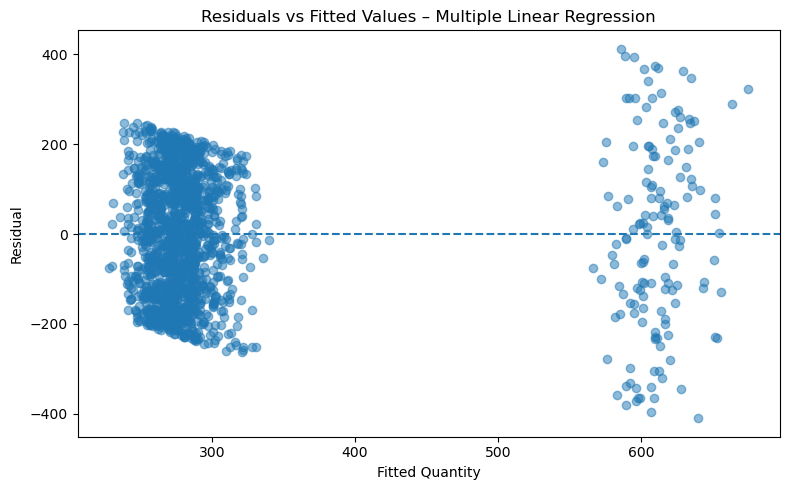

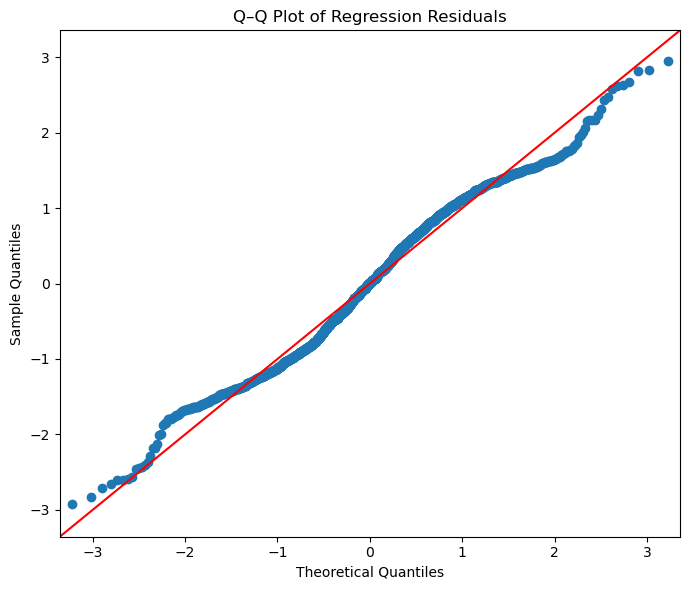

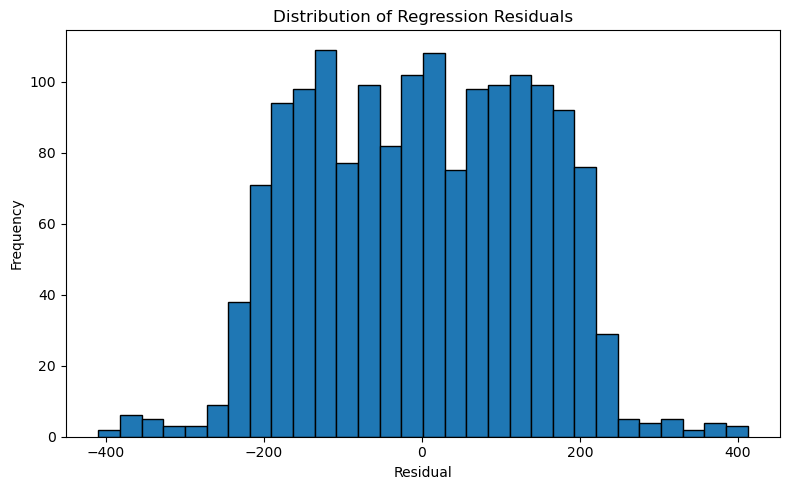

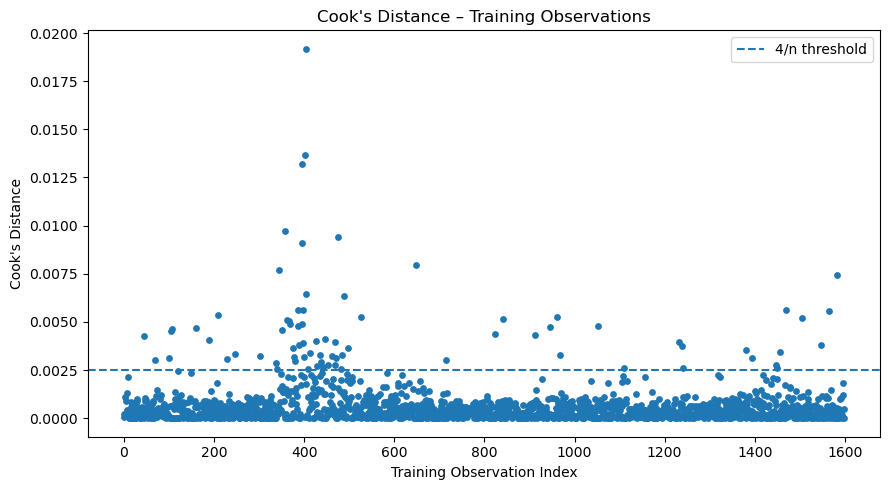


REGRESSION DIAGNOSTIC AUDIT COMPLETE
NO OBSERVATIONS HAVE BEEN REMOVED


In [8]:
# ============================================================
# TASK 5E – MULTIPLE LINEAR REGRESSION DIAGNOSTICS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm

from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ------------------------------------------------------------
# 1. Extract fitted values and residuals
# ------------------------------------------------------------

fitted_values = mlr_model.fittedvalues
residuals = mlr_model.resid

influence = mlr_model.get_influence()

studentized_residuals = influence.resid_studentized_external
leverage = influence.hat_matrix_diag
cooks_distance = influence.cooks_distance[0]

n = int(mlr_model.nobs)
p = int(mlr_model.df_model) + 1   # includes intercept

print("=" * 100)
print("TASK 5E – MULTIPLE LINEAR REGRESSION DIAGNOSTICS")
print("=" * 100)

print(f"\nNumber of observations : {n:,}")
print(f"Number of parameters   : {p}")

# ------------------------------------------------------------
# 2. Residual summary
# ------------------------------------------------------------

print("\n1. RESIDUAL SUMMARY")
print("-" * 100)

residual_summary = pd.Series(residuals).describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

print(residual_summary.round(4).to_string())

print(f"\nResidual mean     : {np.mean(residuals):.8f}")
print(f"Residual skewness : {pd.Series(residuals).skew():.4f}")
print(f"Residual kurtosis : {pd.Series(residuals).kurtosis():.4f}")

# ------------------------------------------------------------
# 3. Formal residual tests
# ------------------------------------------------------------

print("\n2. FORMAL RESIDUAL DIAGNOSTICS")
print("-" * 100)

# Jarque-Bera test
jb_stat, jb_pvalue, jb_skew, jb_kurtosis = jarque_bera(residuals)

print("Jarque-Bera test:")
print(f"Statistic : {jb_stat:.4f}")
print(f"p-value   : {jb_pvalue:.6g}")
print(f"Skewness  : {jb_skew:.4f}")
print(f"Kurtosis  : {jb_kurtosis:.4f}")

# Breusch-Pagan test
bp_test = het_breuschpagan(
    residuals,
    mlr_model.model.exog
)

bp_labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

print("\nBreusch-Pagan test:")

for label, value in zip(bp_labels, bp_test):
    print(f"{label:<15}: {value:.6g}")

# Durbin-Watson
dw_stat = durbin_watson(residuals)

print("\nDurbin-Watson statistic:")
print(f"{dw_stat:.4f}")

print(
    "\nNote: Durbin-Watson is only a supplementary diagnostic here. "
    "Repeated buyer transactions and irregular transaction timing mean "
    "that independence cannot be established from this statistic alone."
)

# ------------------------------------------------------------
# 4. Variance Inflation Factors
# ------------------------------------------------------------

print("\n3. VARIANCE INFLATION FACTORS")
print("-" * 100)

X_design = pd.DataFrame(
    mlr_model.model.exog,
    columns=mlr_model.model.exog_names
)

vif_table = pd.DataFrame({
    "Variable": X_design.columns,
    "VIF": [
        variance_inflation_factor(X_design.values, i)
        for i in range(X_design.shape[1])
    ]
})

# Intercept VIF is not substantively interpreted
vif_table_no_intercept = (
    vif_table[vif_table["Variable"] != "Intercept"]
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

print(
    vif_table_no_intercept
    .round(4)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 5. Influence thresholds
# ------------------------------------------------------------

print("\n4. INFLUENCE DIAGNOSTICS")
print("-" * 100)

cook_threshold = 4 / n
leverage_threshold = 2 * p / n

high_cook = cooks_distance > cook_threshold
high_leverage = leverage > leverage_threshold
large_studentized = np.abs(studentized_residuals) > 3

print(f"Cook's distance threshold (4/n) : {cook_threshold:.6f}")
print(f"Leverage threshold (2p/n)       : {leverage_threshold:.6f}")

print(
    f"\nObservations above Cook threshold : "
    f"{high_cook.sum():,}"
)

print(
    f"Observations above leverage threshold : "
    f"{high_leverage.sum():,}"
)

print(
    f"|Studentized residual| > 3 : "
    f"{large_studentized.sum():,}"
)

# ------------------------------------------------------------
# 6. Build influence table
# ------------------------------------------------------------

diagnostic_table = train_df[
    [
        "Order ID",
        "Date",
        "Product Name",
        "Export Market",
        "Buyer",
        "Quantity",
        "Outlier_IQR_Flag"
    ]
].copy()

diagnostic_table["Fitted_Quantity"] = np.asarray(fitted_values)
diagnostic_table["Residual"] = np.asarray(residuals)
diagnostic_table["Studentized_Residual"] = studentized_residuals
diagnostic_table["Leverage"] = leverage
diagnostic_table["Cooks_Distance"] = cooks_distance

diagnostic_table["High_Cook"] = high_cook
diagnostic_table["High_Leverage"] = high_leverage
diagnostic_table["Large_Studentized_Residual"] = large_studentized

# ------------------------------------------------------------
# 7. Most influential observations
# ------------------------------------------------------------

print("\n5. TOP 15 OBSERVATIONS BY COOK'S DISTANCE")
print("-" * 100)

top_cook = (
    diagnostic_table
    .sort_values("Cooks_Distance", ascending=False)
    .head(15)
)

print(
    top_cook[
        [
            "Order ID",
            "Date",
            "Product Name",
            "Export Market",
            "Buyer",
            "Quantity",
            "Outlier_IQR_Flag",
            "Fitted_Quantity",
            "Residual",
            "Studentized_Residual",
            "Leverage",
            "Cooks_Distance"
        ]
    ]
    .round({
        "Fitted_Quantity": 2,
        "Residual": 2,
        "Studentized_Residual": 3,
        "Leverage": 5,
        "Cooks_Distance": 5
    })
    .to_string(index=False)
)

# ------------------------------------------------------------
# 8. Relationship with previously identified IQR observations
# ------------------------------------------------------------

print("\n6. INFLUENCE VS IQR HIGH-VOLUME FLAG")
print("-" * 100)

if "Outlier_IQR_Flag" in diagnostic_table.columns:

    print(
        pd.crosstab(
            diagnostic_table["Outlier_IQR_Flag"],
            diagnostic_table["High_Cook"],
            margins=True
        ).to_string()
    )

# ------------------------------------------------------------
# 9. Residual vs fitted plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    fitted_values,
    residuals,
    alpha=0.5
)

plt.axhline(0, linestyle="--")

plt.xlabel("Fitted Quantity")
plt.ylabel("Residual")
plt.title("Residuals vs Fitted Values – Multiple Linear Regression")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Q-Q plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

sm.qqplot(
    residuals,
    line="45",
    fit=True,
    ax=plt.gca()
)

plt.title("Q–Q Plot of Regression Residuals")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 11. Histogram of residuals
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Regression Residuals")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 12. Cook's distance plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.scatter(
    np.arange(n),
    cooks_distance,
    s=15
)

plt.axhline(
    cook_threshold,
    linestyle="--",
    label="4/n threshold"
)

plt.xlabel("Training Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance – Training Observations")
plt.legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 100)
print("REGRESSION DIAGNOSTIC AUDIT COMPLETE")
print("NO OBSERVATIONS HAVE BEEN REMOVED")
print("=" * 100)

### 5E.1 Resolving Temporal Multicollinearity Through Training-Only Model Specification Comparison

Regression diagnostics identified severe multicollinearity between the calendar-month indicators and Time Trend. This occurs because the training period contains approximately one complete annual cycle, causing calendar position and chronological progression to overlap strongly.

Consequently, the individual Month and Time Trend coefficients from the initial regression should not be interpreted independently without further specification assessment.

Rather than automatically removing either variable based solely on statistical significance, alternative linear specifications are compared using **chronological validation within the training dataset only**. The final test dataset remains excluded from this model-development decision.

Four candidate specifications are considered:

1. **Full specification:** Product, Market, Month, Day of Week, and Time Trend
2. **Month specification:** Product, Market, Month, and Day of Week
3. **Trend specification:** Product, Market, Day of Week, and Time Trend
4. **Reduced specification:** Product, Market, and Day of Week

An expanding-window, date-aware validation procedure is used so that each validation period occurs strictly after its corresponding training period. This better represents the intended future-prediction setting than random cross-validation.

Models are compared using validation MAE, RMSE, and R². The purpose is not to select a specification based on a trivial difference in one metric, but to determine whether the additional temporal variables provide stable predictive value sufficient to justify their complexity and multicollinearity.

The final holdout period from April–June 2026 is not used during this specification comparison.

In [9]:
# ============================================================
# TASK 5E.1 – TRAINING-ONLY TEMPORAL SPECIFICATION COMPARISON
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import TimeSeriesSplit

# ------------------------------------------------------------
# 1. Prepare TRAINING DATA ONLY
# ------------------------------------------------------------

cv_df = (
    train_df
    .copy()
    .sort_values(["Date", "Order ID"])
    .reset_index(drop=True)
)

# Preserve unique dates so validation never moves backwards in time
unique_dates = np.array(
    sorted(cv_df["Date"].unique())
)

print("=" * 105)
print("TASK 5E.1 – TRAINING-ONLY TEMPORAL SPECIFICATION COMPARISON")
print("=" * 105)

print(f"\nTraining observations : {len(cv_df):,}")
print(f"Unique training dates : {len(unique_dates):,}")
print(
    f"Training period       : "
    f"{cv_df['Date'].min().date()} to "
    f"{cv_df['Date'].max().date()}"
)

# ------------------------------------------------------------
# 2. Candidate linear specifications
# ------------------------------------------------------------

candidate_models = {

    "Full: Product + Market + Month + Day + Trend": {
        "categorical": [
            "Product Name",
            "Export Market",
            "Month",
            "Day_of_Week"
        ],
        "numeric": [
            "Time_Trend"
        ]
    },

    "No Trend: Product + Market + Month + Day": {
        "categorical": [
            "Product Name",
            "Export Market",
            "Month",
            "Day_of_Week"
        ],
        "numeric": []
    },

    "No Month: Product + Market + Day + Trend": {
        "categorical": [
            "Product Name",
            "Export Market",
            "Day_of_Week"
        ],
        "numeric": [
            "Time_Trend"
        ]
    },

    "Reduced: Product + Market + Day": {
        "categorical": [
            "Product Name",
            "Export Market",
            "Day_of_Week"
        ],
        "numeric": []
    }
}

# ------------------------------------------------------------
# 3. Create expanding-window DATE-BASED splits
# ------------------------------------------------------------

# Splitting unique dates prevents transactions from the same date
# being divided between training and validation.
date_tscv = TimeSeriesSplit(n_splits=5)

date_splits = list(
    date_tscv.split(unique_dates)
)

print("\n1. CHRONOLOGICAL VALIDATION FOLDS")
print("-" * 105)

fold_information = []

for fold_number, (train_date_idx, valid_date_idx) in enumerate(
    date_splits,
    start=1
):

    train_dates = unique_dates[train_date_idx]
    valid_dates = unique_dates[valid_date_idx]

    train_mask = cv_df["Date"].isin(train_dates)
    valid_mask = cv_df["Date"].isin(valid_dates)

    fold_train = cv_df.loc[train_mask]
    fold_valid = cv_df.loc[valid_mask]

    fold_information.append({
        "Fold": fold_number,
        "Train_Start": fold_train["Date"].min().date(),
        "Train_End": fold_train["Date"].max().date(),
        "Validation_Start": fold_valid["Date"].min().date(),
        "Validation_End": fold_valid["Date"].max().date(),
        "Train_Rows": len(fold_train),
        "Validation_Rows": len(fold_valid)
    })

fold_info_df = pd.DataFrame(fold_information)

print(
    fold_info_df.to_string(index=False)
)

# ------------------------------------------------------------
# 4. Evaluate each candidate using TRAINING DATA ONLY
# ------------------------------------------------------------

all_fold_results = []

for model_name, specification in candidate_models.items():

    categorical_features = specification["categorical"]
    numeric_features = specification["numeric"]

    feature_columns = (
        categorical_features + numeric_features
    )

    for fold_number, (train_date_idx, valid_date_idx) in enumerate(
        date_splits,
        start=1
    ):

        train_dates = unique_dates[train_date_idx]
        valid_dates = unique_dates[valid_date_idx]

        fold_train = cv_df[
            cv_df["Date"].isin(train_dates)
        ].copy()

        fold_valid = cv_df[
            cv_df["Date"].isin(valid_dates)
        ].copy()

        X_fold_train = fold_train[feature_columns]
        y_fold_train = fold_train["Quantity"]

        X_fold_valid = fold_valid[feature_columns]
        y_fold_valid = fold_valid["Quantity"]

        # ----------------------------------------------------
        # Preprocessing
        # ----------------------------------------------------

        transformers = []

        if categorical_features:
            categorical_transformer = OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )

            transformers.append(
                (
                    "categorical",
                    categorical_transformer,
                    categorical_features
                )
            )

        if numeric_features:
            transformers.append(
                (
                    "numeric",
                    "passthrough",
                    numeric_features
                )
            )

        preprocessor = ColumnTransformer(
            transformers=transformers,
            remainder="drop"
        )

        # ----------------------------------------------------
        # Linear Regression Pipeline
        # ----------------------------------------------------

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("regression", LinearRegression())
        ])

        pipeline.fit(
            X_fold_train,
            y_fold_train
        )

        validation_pred = pipeline.predict(
            X_fold_valid
        )

        mae = mean_absolute_error(
            y_fold_valid,
            validation_pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_fold_valid,
                validation_pred
            )
        )

        r2 = r2_score(
            y_fold_valid,
            validation_pred
        )

        all_fold_results.append({
            "Model": model_name,
            "Fold": fold_number,
            "Train_Rows": len(fold_train),
            "Validation_Rows": len(fold_valid),
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

cv_results = pd.DataFrame(
    all_fold_results
)

# ------------------------------------------------------------
# 5. Display fold-by-fold results
# ------------------------------------------------------------

print("\n2. FOLD-BY-FOLD VALIDATION PERFORMANCE")
print("-" * 105)

for model_name in candidate_models.keys():

    print(f"\n{model_name}")
    print("-" * 105)

    model_fold_results = (
        cv_results[
            cv_results["Model"] == model_name
        ][
            [
                "Fold",
                "Train_Rows",
                "Validation_Rows",
                "MAE",
                "RMSE",
                "R2"
            ]
        ]
        .copy()
    )

    print(
        model_fold_results
        .round(4)
        .to_string(index=False)
    )

# ------------------------------------------------------------
# 6. Summarize average chronological-validation performance
# ------------------------------------------------------------

cv_summary = (
    cv_results
    .groupby("Model")
    .agg(
        Mean_MAE=("MAE", "mean"),
        SD_MAE=("MAE", "std"),
        Mean_RMSE=("RMSE", "mean"),
        SD_RMSE=("RMSE", "std"),
        Mean_R2=("R2", "mean"),
        SD_R2=("R2", "std")
    )
    .reset_index()
    .sort_values("Mean_RMSE")
)

print("\n3. AVERAGE CHRONOLOGICAL VALIDATION PERFORMANCE")
print("-" * 105)

print(
    cv_summary
    .round(4)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 7. Performance range / stability
# ------------------------------------------------------------

cv_stability = (
    cv_results
    .groupby("Model")
    .agg(
        Best_MAE=("MAE", "min"),
        Worst_MAE=("MAE", "max"),
        Best_RMSE=("RMSE", "min"),
        Worst_RMSE=("RMSE", "max"),
        Min_R2=("R2", "min"),
        Max_R2=("R2", "max")
    )
    .reset_index()
)

print("\n4. VALIDATION STABILITY")
print("-" * 105)

print(
    cv_stability
    .round(4)
    .to_string(index=False)
)

print("\n" + "=" * 105)
print("TRAINING-ONLY SPECIFICATION COMPARISON COMPLETE")
print("FINAL APRIL–JUNE 2026 TEST SET HAS NOT BEEN USED")
print("=" * 105)

TASK 5E.1 – TRAINING-ONLY TEMPORAL SPECIFICATION COMPARISON

Training observations : 1,599
Unique training dates : 257
Training period       : 2025-04-01 to 2026-03-31

1. CHRONOLOGICAL VALIDATION FOLDS
---------------------------------------------------------------------------------------------------------
 Fold Train_Start  Train_End Validation_Start Validation_End  Train_Rows  Validation_Rows
    1  2025-04-01 2025-05-31       2025-06-02     2025-09-09         372               67
    2  2025-04-01 2025-09-09       2025-09-10     2025-11-12         439              127
    3  2025-04-01 2025-11-12       2025-11-13     2025-12-25         566              411
    4  2025-04-01 2025-12-25       2025-12-26     2026-02-12         977              440
    5  2025-04-01 2026-02-12       2026-02-13     2026-03-31        1417              182


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Foun


2. FOLD-BY-FOLD VALIDATION PERFORMANCE
---------------------------------------------------------------------------------------------------------

Full: Product + Market + Month + Day + Trend
---------------------------------------------------------------------------------------------------------
 Fold  Train_Rows  Validation_Rows      MAE     RMSE      R2
    1         372               67 119.0139 141.9870  0.2913
    2         439              127 146.7008 183.4105 -0.4623
    3         566              411 143.8205 174.7010 -0.0762
    4         977              440 117.5967 136.2638  0.3090
    5        1417              182 110.4628 136.7614  0.2947

No Trend: Product + Market + Month + Day
---------------------------------------------------------------------------------------------------------
 Fold  Train_Rows  Validation_Rows      MAE     RMSE     R2
    1         372               67 109.9950 130.9786 0.3969
    2         439              127 114.3448 139.2346 0.1573
    3   

### 5E.2 Final Interpretable Linear Regression Specification

Training-only chronological validation showed that the simpler specification containing **Product Name, Export Market, and Day of Week** provided the strongest balance of predictive performance, stability, interpretability, and parsimony.

The reduced specification achieved the lowest average validation MAE and RMSE among the candidate linear models. Adding Month produced almost no improvement, while adding Time Trend substantially reduced validation stability and predictive performance. The combination of Month and Time Trend also produced severe multicollinearity in the initial model.

The final interpretable Multiple Linear Regression specification is therefore:

\[
Quantity_i =
\beta_0 +
\beta_{Product} +
\beta_{Market} +
\beta_{Day} +
\epsilon_i
\]

The reference categories remain:

- **Product Name:** Dark Matrix
- **Export Market:** Local
- **Day of Week:** Monday

Because the earlier regression diagnostics identified statistically significant heteroscedasticity, coefficient uncertainty is estimated using **HC3 heteroscedasticity-robust standard errors**. HC3 does not change the estimated regression coefficients or predictions; instead, it provides standard errors, confidence intervals, and significance tests that are more robust to unequal residual variance.

HC3 does not solve all dependence concerns. Multiple historical transactions belong to the same buyers, and the current-regime dataset contains only a small number of buyers. Therefore, coefficient inference remains observational and should not be interpreted causally.

The selected model is evaluated on the chronologically later April–June 2026 test period using MAE, RMSE, and R².

In [10]:
# ============================================================
# TASK 5E.2 – FINAL INTERPRETABLE MLR WITH HC3 ROBUST SE
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ------------------------------------------------------------
# 1. Prepare selected-model datasets
# ------------------------------------------------------------

final_mlr_train = train_df[
    [
        "Quantity",
        "Product Name",
        "Export Market",
        "Day_of_Week"
    ]
].copy()

final_mlr_test = test_df[
    [
        "Quantity",
        "Product Name",
        "Export Market",
        "Day_of_Week"
    ]
].copy()

# ------------------------------------------------------------
# 2. Final selected regression formula
# ------------------------------------------------------------

final_mlr_formula = """
Q("Quantity")
~
C(Q("Product Name"), Treatment(reference="Dark Matrix"))
+
C(Q("Export Market"), Treatment(reference="Local"))
+
C(Q("Day_of_Week"), Treatment(reference="Monday"))
"""

# ------------------------------------------------------------
# 3. Fit conventional OLS coefficients
# ------------------------------------------------------------

final_mlr_model = smf.ols(
    formula=final_mlr_formula,
    data=final_mlr_train
).fit()

# HC3 robust covariance version of the SAME fitted model
final_mlr_hc3 = final_mlr_model.get_robustcov_results(
    cov_type="HC3"
)

print("=" * 105)
print("TASK 5E.2 – FINAL INTERPRETABLE MLR WITH HC3 ROBUST STANDARD ERRORS")
print("=" * 105)

# ------------------------------------------------------------
# 4. Overall model fit
# ------------------------------------------------------------

print("\n1. OVERALL MODEL FIT")
print("-" * 105)

print(f"Observations          : {int(final_mlr_model.nobs):,}")
print(f"R-squared             : {final_mlr_model.rsquared:.6f}")
print(f"Adjusted R-squared    : {final_mlr_model.rsquared_adj:.6f}")
print(f"AIC                   : {final_mlr_model.aic:.2f}")
print(f"BIC                   : {final_mlr_model.bic:.2f}")

# ------------------------------------------------------------
# 5. HC3 robust coefficient table
# ------------------------------------------------------------

parameter_names = final_mlr_model.params.index

hc3_conf_int = final_mlr_hc3.conf_int()

hc3_coefficient_table = pd.DataFrame({
    "Variable": parameter_names,
    "Coefficient": final_mlr_hc3.params,
    "HC3_SE": final_mlr_hc3.bse,
    "t_value": final_mlr_hc3.tvalues,
    "p_value": final_mlr_hc3.pvalues,
    "CI_2.5%": hc3_conf_int[:, 0],
    "CI_97.5%": hc3_conf_int[:, 1]
})

print("\n2. HC3 ROBUST REGRESSION COEFFICIENTS")
print("-" * 105)

print(
    hc3_coefficient_table
    .round({
        "Coefficient": 4,
        "HC3_SE": 4,
        "t_value": 4,
        "p_value": 6,
        "CI_2.5%": 4,
        "CI_97.5%": 4
    })
    .to_string(index=False)
)

# ------------------------------------------------------------
# 6. Compare conventional vs HC3 standard errors
# ------------------------------------------------------------

se_comparison = pd.DataFrame({
    "Variable": parameter_names,
    "Conventional_SE": final_mlr_model.bse.values,
    "HC3_SE": final_mlr_hc3.bse
})

se_comparison["SE_Change_Percent"] = (
    (
        se_comparison["HC3_SE"]
        - se_comparison["Conventional_SE"]
    )
    / se_comparison["Conventional_SE"]
    * 100
)

print("\n3. CONVENTIONAL VS HC3 STANDARD ERRORS")
print("-" * 105)

print(
    se_comparison
    .round(4)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 7. Check multicollinearity in selected specification
# ------------------------------------------------------------

print("\n4. FINAL-SPECIFICATION VIF")
print("-" * 105)

X_final_design = pd.DataFrame(
    final_mlr_model.model.exog,
    columns=final_mlr_model.model.exog_names
)

final_vif = pd.DataFrame({
    "Variable": X_final_design.columns,
    "VIF": [
        variance_inflation_factor(
            X_final_design.values,
            i
        )
        for i in range(X_final_design.shape[1])
    ]
})

final_vif = (
    final_vif[
        final_vif["Variable"] != "Intercept"
    ]
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

print(
    final_vif
    .round(4)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 8. Recheck residual distribution and heteroscedasticity
# ------------------------------------------------------------

final_residuals = final_mlr_model.resid

jb_stat, jb_pvalue, jb_skew, jb_kurtosis = jarque_bera(
    final_residuals
)

bp_test = het_breuschpagan(
    final_residuals,
    final_mlr_model.model.exog
)

print("\n5. RESIDUAL DIAGNOSTIC RECHECK")
print("-" * 105)

print("Jarque-Bera:")
print(f"Statistic : {jb_stat:.4f}")
print(f"p-value   : {jb_pvalue:.6g}")
print(f"Skewness  : {jb_skew:.4f}")
print(f"Kurtosis  : {jb_kurtosis:.4f}")

print("\nBreusch-Pagan:")
print(f"LM Statistic : {bp_test[0]:.4f}")
print(f"LM p-value   : {bp_test[1]:.6g}")
print(f"F Statistic  : {bp_test[2]:.4f}")
print(f"F p-value    : {bp_test[3]:.6g}")

# ------------------------------------------------------------
# 9. Generate predictions
# ------------------------------------------------------------

final_mlr_train_pred = final_mlr_model.predict(
    final_mlr_train
)

final_mlr_test_pred = final_mlr_model.predict(
    final_mlr_test
)

# ------------------------------------------------------------
# 10. Predictive performance
# ------------------------------------------------------------

final_mlr_train_metrics = regression_metrics(
    y_train,
    final_mlr_train_pred
)

final_mlr_test_metrics = regression_metrics(
    y_test,
    final_mlr_test_pred
)

final_mlr_performance = pd.DataFrame({
    "Training": final_mlr_train_metrics,
    "Testing": final_mlr_test_metrics
}).T

print("\n6. FINAL MLR PREDICTIVE PERFORMANCE")
print("-" * 105)

print(
    final_mlr_performance
    .round(4)
    .to_string()
)

# ------------------------------------------------------------
# 11. Compare with baseline and original full MLR
# ------------------------------------------------------------

final_comparison = pd.DataFrame([
    {
        "Model": "Training Mean Baseline",
        "Train_MAE": baseline_train_metrics["MAE"],
        "Train_RMSE": baseline_train_metrics["RMSE"],
        "Train_R2": baseline_train_metrics["R2"],
        "Test_MAE": baseline_test_metrics["MAE"],
        "Test_RMSE": baseline_test_metrics["RMSE"],
        "Test_R2": baseline_test_metrics["R2"]
    },

    {
        "Model": "Initial Full MLR",
        "Train_MAE": mlr_train_metrics["MAE"],
        "Train_RMSE": mlr_train_metrics["RMSE"],
        "Train_R2": mlr_train_metrics["R2"],
        "Test_MAE": mlr_test_metrics["MAE"],
        "Test_RMSE": mlr_test_metrics["RMSE"],
        "Test_R2": mlr_test_metrics["R2"]
    },

    {
        "Model": "Selected Reduced MLR",
        "Train_MAE": final_mlr_train_metrics["MAE"],
        "Train_RMSE": final_mlr_train_metrics["RMSE"],
        "Train_R2": final_mlr_train_metrics["R2"],
        "Test_MAE": final_mlr_test_metrics["MAE"],
        "Test_RMSE": final_mlr_test_metrics["RMSE"],
        "Test_R2": final_mlr_test_metrics["R2"]
    }
])

print("\n7. MODEL PERFORMANCE COMPARISON")
print("-" * 105)

print(
    final_comparison
    .round(4)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 12. Improvement over baseline
# ------------------------------------------------------------

final_mae_improvement_pct = (
    (
        baseline_test_metrics["MAE"]
        - final_mlr_test_metrics["MAE"]
    )
    / baseline_test_metrics["MAE"]
    * 100
)

final_rmse_improvement_pct = (
    (
        baseline_test_metrics["RMSE"]
        - final_mlr_test_metrics["RMSE"]
    )
    / baseline_test_metrics["RMSE"]
    * 100
)

print("\n8. SELECTED MLR IMPROVEMENT OVER BASELINE")
print("-" * 105)

print(
    f"Test MAE improvement  : "
    f"{final_mae_improvement_pct:.2f}%"
)

print(
    f"Test RMSE improvement : "
    f"{final_rmse_improvement_pct:.2f}%"
)

# ------------------------------------------------------------
# 13. Prediction range
# ------------------------------------------------------------

print("\n9. PREDICTION RANGE")
print("-" * 105)

print(
    f"Training predictions : "
    f"{final_mlr_train_pred.min():.2f} to "
    f"{final_mlr_train_pred.max():.2f}"
)

print(
    f"Test predictions     : "
    f"{final_mlr_test_pred.min():.2f} to "
    f"{final_mlr_test_pred.max():.2f}"
)

print(
    f"Negative test predictions : "
    f"{(final_mlr_test_pred < 0).sum()}"
)

# ------------------------------------------------------------
# 14. Save/update model comparison table
# ------------------------------------------------------------

model_results = final_comparison.copy()

print("\n" + "=" * 105)
print("FINAL INTERPRETABLE MLR REFIT COMPLETE")
print("HC3 ROBUST STANDARD ERRORS APPLIED")
print("=" * 105)

TASK 5E.2 – FINAL INTERPRETABLE MLR WITH HC3 ROBUST STANDARD ERRORS

1. OVERALL MODEL FIT
---------------------------------------------------------------------------------------------------------
Observations          : 1,599
R-squared             : 0.318380
Adjusted R-squared    : 0.314088
AIC                   : 20381.37
BIC                   : 20440.52

2. HC3 ROBUST REGRESSION COEFFICIENTS
---------------------------------------------------------------------------------------------------------
                                                                   Variable  Coefficient  HC3_SE  t_value  p_value  CI_2.5%  CI_97.5%
                                                                  Intercept     264.1415 11.1479  23.6943 0.000000 242.2754  286.0077
        C(Q("Product Name"), Treatment(reference="Dark Matrix"))[T.Kennedy]       2.5854 10.0637   0.2569 0.797287 -17.1541   22.3249
      C(Q("Product Name"), Treatment(reference="Dark Matrix"))[T.Mesmerose]      -6.2844  9.925

## 5F – Poisson Generalized Linear Model

Because **Quantity** is a positive integer-valued response, a Poisson Generalized Linear Model (GLM) is investigated as an alternative to ordinary linear regression.

The Poisson model uses the same reduced predictor structure selected for the final interpretable MLR:

- Product Name
- Export Market
- Day of Week

The model uses a log link, so exponentiated coefficients are interpreted as multiplicative changes in expected Quantity, holding the other included variables constant.

A key Poisson assumption is that the conditional variance is approximately equal to the conditional mean. Therefore, the **Pearson dispersion ratio** and residual-deviance ratio are calculated. A dispersion ratio much larger than 1 indicates overdispersion and motivates a Negative Binomial model.

> **Interpretation warning:** Export Market is observational and structurally linked to the Japan buyer pattern. Any market coefficient is an association, not a causal effect.

In [ ]:
# ============================================================
# TASK 5F – POISSON GENERALIZED LINEAR MODEL
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

poisson_formula = """
Q("Quantity")
~
C(Q("Product Name"), Treatment(reference="Dark Matrix"))
+
C(Q("Export Market"), Treatment(reference="Local"))
+
C(Q("Day_of_Week"), Treatment(reference="Monday"))
"""

poisson_model = smf.glm(
    formula=poisson_formula,
    data=train_df,
    family=sm.families.Poisson(link=sm.families.links.Log())
).fit()

print("=" * 105)
print("TASK 5F – POISSON GLM")
print("=" * 105)
print(poisson_model.summary())

poisson_train_pred = poisson_model.predict(train_df)
poisson_test_pred = poisson_model.predict(test_df)

poisson_train_metrics = regression_metrics(y_train, poisson_train_pred)
poisson_test_metrics = regression_metrics(y_test, poisson_test_pred)

print("\n1. POISSON PREDICTIVE PERFORMANCE")
print("-" * 105)

poisson_performance = pd.DataFrame({
    "Training": poisson_train_metrics,
    "Testing": poisson_test_metrics
}).T
print(poisson_performance.round(4).to_string())

print("\n2. POISSON MODEL-FIT STATISTICS")
print("-" * 105)
print(f"AIC               : {poisson_model.aic:.4f}")
print(f"Residual deviance : {poisson_model.deviance:.4f}")
print(f"Residual df       : {int(poisson_model.df_resid):,}")

pearson_chi2 = np.sum(poisson_model.resid_pearson ** 2)
poisson_dispersion = pearson_chi2 / poisson_model.df_resid
poisson_deviance_ratio = poisson_model.deviance / poisson_model.df_resid

print("\n3. POISSON OVERDISPERSION CHECK")
print("-" * 105)
print(f"Pearson Chi-square       : {pearson_chi2:.4f}")
print(f"Pearson dispersion ratio : {poisson_dispersion:.4f}")
print(f"Residual deviance / df   : {poisson_deviance_ratio:.4f}")

if poisson_dispersion > 1.5:
    print(
        "\nConclusion: Strong overdispersion is present. "
        "The ordinary Poisson mean-variance assumption is not adequate."
    )
else:
    print(
        "\nConclusion: Strong overdispersion was not detected "
        "by the Pearson dispersion ratio."
    )

poisson_coef = pd.DataFrame({
    "Coefficient": poisson_model.params,
    "Std_Error": poisson_model.bse,
    "z_value": poisson_model.tvalues,
    "p_value": poisson_model.pvalues,
    "IRR": np.exp(poisson_model.params)
})

print("\n4. POISSON COEFFICIENTS AND IRR")
print("-" * 105)
print(poisson_coef.round(6).to_string())

print("\n" + "=" * 105)
print("POISSON GLM COMPLETE")
print("=" * 105)

## 5G – Negative Binomial Regression

The Poisson diagnostic is expected to show substantial overdispersion in transaction Quantity. A **Negative Binomial model** is therefore investigated because it allows the variance to exceed the conditional mean.

The same reduced predictor set is retained so that the distributional assumption can be compared directly with the final MLR and Poisson models.

The model estimates an additional dispersion parameter. In the `statsmodels` discrete Negative Binomial parameterization, the estimated `alpha` controls extra-Poisson variation; the corresponding `theta` value is reported as \(1/lpha\) for comparison with the R `glm.nb()` result.

Exponentiated coefficients are interpreted as multiplicative associations with expected Quantity, holding the other included predictors constant.

In [ ]:
# ============================================================
# TASK 5G – NEGATIVE BINOMIAL REGRESSION
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

nb_model = smf.negativebinomial(
    formula=poisson_formula,
    data=train_df
).fit(
    disp=False,
    maxiter=200
)

print("=" * 105)
print("TASK 5G – NEGATIVE BINOMIAL REGRESSION")
print("=" * 105)
print(nb_model.summary())

nb_train_pred = nb_model.predict(train_df)
nb_test_pred = nb_model.predict(test_df)

nb_train_metrics = regression_metrics(y_train, nb_train_pred)
nb_test_metrics = regression_metrics(y_test, nb_test_pred)

print("\n1. NEGATIVE BINOMIAL PREDICTIVE PERFORMANCE")
print("-" * 105)

nb_performance = pd.DataFrame({
    "Training": nb_train_metrics,
    "Testing": nb_test_metrics
}).T
print(nb_performance.round(4).to_string())

nb_alpha = float(nb_model.params.get("alpha", np.nan))
nb_theta = (1.0 / nb_alpha) if np.isfinite(nb_alpha) and nb_alpha > 0 else np.nan

print("\n2. NEGATIVE BINOMIAL MODEL-FIT STATISTICS")
print("-" * 105)
print(f"AIC            : {nb_model.aic:.4f}")
print(f"Estimated alpha: {nb_alpha:.6f}")
print(f"Theta = 1/alpha: {nb_theta:.4f}")

nb_params = nb_model.params.drop(labels=["alpha"], errors="ignore")
nb_coef = pd.DataFrame({
    "Coefficient": nb_params,
    "Std_Error": nb_model.bse.reindex(nb_params.index),
    "z_value": nb_model.tvalues.reindex(nb_params.index),
    "p_value": nb_model.pvalues.reindex(nb_params.index),
    "Multiplicative_Effect": np.exp(nb_params)
})

print("\n3. NEGATIVE BINOMIAL COEFFICIENTS")
print("-" * 105)
print(nb_coef.round(6).to_string())

print("\n" + "=" * 105)
print("NEGATIVE BINOMIAL REGRESSION COMPLETE")
print("=" * 105)

## 5H – Regularized Regression

Ridge, LASSO, and Elastic Net are evaluated as alternative Gaussian regression approaches.

The regularized models use the broader candidate predictor set:

- Product Name
- Export Market
- Month
- Day of Week
- Time Trend

Categorical predictors are one-hot encoded and all encoded predictors are standardized within each training fold.

### Validation strategy

Hyperparameters are tuned using the **same expanding-window, date-based chronological validation folds** already created in Section 5E.1. The April–June 2026 holdout period remains untouched until final evaluation.

- Ridge tunes the penalty strength
- LASSO tunes the penalty strength and can set coefficients exactly to zero
- Elastic Net tunes both the L1 mixing value and regularization strength

In [ ]:
# ============================================================
# TASK 5H – REGULARIZED REGRESSION SETUP
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet

regularized_categorical = [
    "Product Name",
    "Export Market",
    "Month",
    "Day_of_Week"
]

regularized_numeric = [
    "Time_Trend"
]

regularized_features = regularized_categorical + regularized_numeric

def make_regularized_pipeline(model):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first",
                    sparse_output=False
                ),
                regularized_categorical
            ),
            (
                "numeric",
                "passthrough",
                regularized_numeric
            )
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

    return Pipeline([
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler()),
        ("model", model)
    ])


def evaluate_regularized_parameter(
    model_builder,
    parameter_values,
    parameter_name
):
    rows = []

    for parameter_value in parameter_values:

        for fold_number, (train_date_idx, valid_date_idx) in enumerate(
            date_splits,
            start=1
        ):
            fold_train_dates = unique_dates[train_date_idx]
            fold_valid_dates = unique_dates[valid_date_idx]

            fold_train = cv_df[
                cv_df["Date"].isin(fold_train_dates)
            ].copy()

            fold_valid = cv_df[
                cv_df["Date"].isin(fold_valid_dates)
            ].copy()

            X_fold_train = fold_train[regularized_features]
            y_fold_train = fold_train["Quantity"]

            X_fold_valid = fold_valid[regularized_features]
            y_fold_valid = fold_valid["Quantity"]

            pipeline = make_regularized_pipeline(
                model_builder(parameter_value)
            )

            pipeline.fit(X_fold_train, y_fold_train)
            valid_pred = pipeline.predict(X_fold_valid)

            metrics = regression_metrics(
                y_fold_valid,
                valid_pred
            )

            rows.append({
                parameter_name: parameter_value,
                "Fold": fold_number,
                "Train_Rows": len(fold_train),
                "Validation_Rows": len(fold_valid),
                "MAE": metrics["MAE"],
                "RMSE": metrics["RMSE"],
                "R2": metrics["R2"]
            })

    results = pd.DataFrame(rows)

    summary = (
        results
        .groupby(parameter_name)
        .agg(
            Mean_MAE=("MAE", "mean"),
            SD_MAE=("MAE", "std"),
            Mean_RMSE=("RMSE", "mean"),
            SD_RMSE=("RMSE", "std"),
            Mean_R2=("R2", "mean"),
            SD_R2=("R2", "std")
        )
        .reset_index()
        .sort_values("Mean_RMSE")
        .reset_index(drop=True)
    )

    return results, summary


print("=" * 105)
print("TASK 5H – REGULARIZED REGRESSION SETUP")
print("=" * 105)
print(f"\nTraining observations : {len(train_df):,}")
print(f"Test observations     : {len(test_df):,}")
print(f"Chronological folds   : {len(date_splits)}")
print(f"Predictors            : {regularized_features}")

print("\n" + "=" * 105)
print("REGULARIZED REGRESSION SETUP COMPLETE")
print("=" * 105)

### 5H.1 – Ridge Regression

Ridge regression applies an L2 penalty. It is useful when predictors are correlated because it shrinks coefficients toward zero without automatically deleting them.

The penalty strength is selected using the training-only chronological validation folds. The final tuned model is then refitted to all training observations and evaluated once on the April–June 2026 holdout period.

In [ ]:
# ============================================================
# TASK 5H.1 – RIDGE REGRESSION
# ============================================================

ridge_alpha_grid = np.logspace(-2, 3, 80)

ridge_cv_results, ridge_cv_summary = evaluate_regularized_parameter(
    model_builder=lambda alpha_value: Ridge(alpha=alpha_value),
    parameter_values=ridge_alpha_grid,
    parameter_name="Alpha"
)

best_ridge_alpha = float(ridge_cv_summary.loc[0, "Alpha"])

print("=" * 105)
print("TASK 5H.1 – RIDGE REGRESSION")
print("=" * 105)
print(f"\nBest Ridge alpha: {best_ridge_alpha:.6f}")

print("\n1. TOP RIDGE VALIDATION RESULTS")
print("-" * 105)
print(ridge_cv_summary.head(10).round(6).to_string(index=False))

ridge_final = make_regularized_pipeline(
    Ridge(alpha=best_ridge_alpha)
)

ridge_final.fit(
    train_df[regularized_features],
    y_train
)

ridge_train_pred = ridge_final.predict(
    train_df[regularized_features]
)

ridge_test_pred = ridge_final.predict(
    test_df[regularized_features]
)

ridge_train_metrics = regression_metrics(y_train, ridge_train_pred)
ridge_test_metrics = regression_metrics(y_test, ridge_test_pred)

print("\n2. RIDGE FINAL PERFORMANCE")
print("-" * 105)

ridge_performance = pd.DataFrame({
    "Training": ridge_train_metrics,
    "Testing": ridge_test_metrics
}).T
print(ridge_performance.round(4).to_string())

print("\n" + "=" * 105)
print("RIDGE REGRESSION COMPLETE")
print("=" * 105)

### 5H.2 – LASSO Regression

LASSO applies an L1 penalty. In addition to regularization, sufficiently strong penalties can shrink some encoded predictor coefficients exactly to zero.

The penalty strength is tuned using chronological validation. After fitting the final model, the retained and zeroed encoded predictors are reported to show the variable-selection behavior of LASSO.

In [ ]:
# ============================================================
# TASK 5H.2 – LASSO REGRESSION
# ============================================================

lasso_alpha_grid = np.logspace(-2, 2, 80)

lasso_cv_results, lasso_cv_summary = evaluate_regularized_parameter(
    model_builder=lambda alpha_value: Lasso(
        alpha=alpha_value,
        max_iter=200000
    ),
    parameter_values=lasso_alpha_grid,
    parameter_name="Alpha"
)

best_lasso_alpha = float(lasso_cv_summary.loc[0, "Alpha"])

print("=" * 105)
print("TASK 5H.2 – LASSO REGRESSION")
print("=" * 105)
print(f"\nBest LASSO alpha: {best_lasso_alpha:.6f}")

print("\n1. TOP LASSO VALIDATION RESULTS")
print("-" * 105)
print(lasso_cv_summary.head(10).round(6).to_string(index=False))

lasso_final = make_regularized_pipeline(
    Lasso(
        alpha=best_lasso_alpha,
        max_iter=200000
    )
)

lasso_final.fit(
    train_df[regularized_features],
    y_train
)

lasso_train_pred = lasso_final.predict(
    train_df[regularized_features]
)

lasso_test_pred = lasso_final.predict(
    test_df[regularized_features]
)

lasso_train_metrics = regression_metrics(y_train, lasso_train_pred)
lasso_test_metrics = regression_metrics(y_test, lasso_test_pred)

print("\n2. LASSO FINAL PERFORMANCE")
print("-" * 105)

lasso_performance = pd.DataFrame({
    "Training": lasso_train_metrics,
    "Testing": lasso_test_metrics
}).T
print(lasso_performance.round(4).to_string())

lasso_feature_names = (
    lasso_final
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

lasso_coefficients = lasso_final.named_steps["model"].coef_

lasso_coef_table = pd.DataFrame({
    "Variable": lasso_feature_names,
    "Coefficient": lasso_coefficients
})

lasso_selected = lasso_coef_table[
    ~np.isclose(lasso_coef_table["Coefficient"], 0.0, atol=1e-10)
].copy()

lasso_dropped = lasso_coef_table[
    np.isclose(lasso_coef_table["Coefficient"], 0.0, atol=1e-10)
].copy()

print("\n3. LASSO RETAINED ENCODED PREDICTORS")
print("-" * 105)
print(lasso_selected.round(6).to_string(index=False))

print("\n4. LASSO PREDICTORS SHRUNK TO ZERO")
print("-" * 105)
print(lasso_dropped.round(6).to_string(index=False))

print(
    f"\nLASSO retained {len(lasso_selected)} of "
    f"{len(lasso_coef_table)} encoded predictors."
)

print("\n" + "=" * 105)
print("LASSO REGRESSION COMPLETE")
print("=" * 105)

### 5H.3 – Elastic Net Regression

Elastic Net combines L1 and L2 penalties. This can be useful when correlated predictors exist but some automatic coefficient selection is also desirable.

Three mixing values are investigated:

- `l1_ratio = 0.25`
- `l1_ratio = 0.50`
- `l1_ratio = 0.75`

For each mixing value, regularization strength is tuned using the same chronological validation folds. The combination with the lowest mean validation RMSE is selected before the untouched test set is evaluated.

In [ ]:
# ============================================================
# TASK 5H.3 – ELASTIC NET REGRESSION
# ============================================================

elastic_l1_ratios = [0.25, 0.50, 0.75]
elastic_alpha_grid = np.logspace(-2, 2, 60)

elastic_fold_tables = []
elastic_summary_tables = []

print("=" * 105)
print("TASK 5H.3 – ELASTIC NET REGRESSION")
print("=" * 105)

for l1_ratio_value in elastic_l1_ratios:

    fold_results, alpha_summary = evaluate_regularized_parameter(
        model_builder=lambda alpha_value, l1=l1_ratio_value: ElasticNet(
            alpha=alpha_value,
            l1_ratio=l1,
            max_iter=200000
        ),
        parameter_values=elastic_alpha_grid,
        parameter_name="Alpha"
    )

    fold_results["L1_Ratio"] = l1_ratio_value
    alpha_summary["L1_Ratio"] = l1_ratio_value

    elastic_fold_tables.append(fold_results)
    elastic_summary_tables.append(alpha_summary)

elastic_cv_results = pd.concat(
    elastic_fold_tables,
    ignore_index=True
)

elastic_cv_summary = (
    pd.concat(
        elastic_summary_tables,
        ignore_index=True
    )
    .sort_values("Mean_RMSE")
    .reset_index(drop=True)
)

best_elastic_alpha = float(
    elastic_cv_summary.loc[0, "Alpha"]
)

best_elastic_l1_ratio = float(
    elastic_cv_summary.loc[0, "L1_Ratio"]
)

print(f"\nBest Elastic Net l1_ratio: {best_elastic_l1_ratio:.2f}")
print(f"Best Elastic Net alpha   : {best_elastic_alpha:.6f}")

print("\n1. TOP ELASTIC NET VALIDATION RESULTS")
print("-" * 105)

print(
    elastic_cv_summary[
        [
            "L1_Ratio",
            "Alpha",
            "Mean_MAE",
            "SD_MAE",
            "Mean_RMSE",
            "SD_RMSE",
            "Mean_R2",
            "SD_R2"
        ]
    ]
    .head(15)
    .round(6)
    .to_string(index=False)
)

elastic_final = make_regularized_pipeline(
    ElasticNet(
        alpha=best_elastic_alpha,
        l1_ratio=best_elastic_l1_ratio,
        max_iter=200000
    )
)

elastic_final.fit(
    train_df[regularized_features],
    y_train
)

elastic_train_pred = elastic_final.predict(
    train_df[regularized_features]
)

elastic_test_pred = elastic_final.predict(
    test_df[regularized_features]
)

elastic_train_metrics = regression_metrics(
    y_train,
    elastic_train_pred
)

elastic_test_metrics = regression_metrics(
    y_test,
    elastic_test_pred
)

print("\n2. ELASTIC NET FINAL PERFORMANCE")
print("-" * 105)

elastic_performance = pd.DataFrame({
    "Training": elastic_train_metrics,
    "Testing": elastic_test_metrics
}).T
print(elastic_performance.round(4).to_string())

elastic_feature_names = (
    elastic_final
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

elastic_coefficients = elastic_final.named_steps["model"].coef_

elastic_coef_table = pd.DataFrame({
    "Variable": elastic_feature_names,
    "Coefficient": elastic_coefficients
})

elastic_selected = elastic_coef_table[
    ~np.isclose(elastic_coef_table["Coefficient"], 0.0, atol=1e-10)
].copy()

elastic_dropped = elastic_coef_table[
    np.isclose(elastic_coef_table["Coefficient"], 0.0, atol=1e-10)
].copy()

print("\n3. ELASTIC NET RETAINED ENCODED PREDICTORS")
print("-" * 105)
print(elastic_selected.round(6).to_string(index=False))

print("\n" + "=" * 105)
print("ELASTIC NET REGRESSION COMPLETE")
print("=" * 105)

## 5I – Final Predictive Model Comparison

All models are compared on the same chronological holdout period, April–June 2026.

The comparison includes:

- Training-mean baseline
- Selected Reduced MLR
- Poisson GLM
- Negative Binomial
- Ridge
- LASSO
- Elastic Net

The key holdout metrics are MAE, RMSE, and \(R^2\). AIC is shown only for likelihood-based models where it is directly available.

**Model selection is not based on prediction accuracy alone.** The final organizational recommendation must also consider assumptions, interpretability, robustness, complexity, ease of implementation, and business usefulness.

The R analysis remains the official project implementation. This notebook provides a complete Python-side replication/supporting workflow.

In [ ]:
# ============================================================
# TASK 5I – FINAL MODEL COMPARISON
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

final_model_comparison = pd.DataFrame([
    {
        "Model": "Training Mean Baseline",
        "Train_MAE": baseline_train_metrics["MAE"],
        "Train_RMSE": baseline_train_metrics["RMSE"],
        "Train_R2": baseline_train_metrics["R2"],
        "Test_MAE": baseline_test_metrics["MAE"],
        "Test_RMSE": baseline_test_metrics["RMSE"],
        "Test_R2": baseline_test_metrics["R2"],
        "AIC": np.nan
    },
    {
        "Model": "Reduced MLR",
        "Train_MAE": final_mlr_train_metrics["MAE"],
        "Train_RMSE": final_mlr_train_metrics["RMSE"],
        "Train_R2": final_mlr_train_metrics["R2"],
        "Test_MAE": final_mlr_test_metrics["MAE"],
        "Test_RMSE": final_mlr_test_metrics["RMSE"],
        "Test_R2": final_mlr_test_metrics["R2"],
        "AIC": final_mlr_model.aic
    },
    {
        "Model": "Poisson GLM",
        "Train_MAE": poisson_train_metrics["MAE"],
        "Train_RMSE": poisson_train_metrics["RMSE"],
        "Train_R2": poisson_train_metrics["R2"],
        "Test_MAE": poisson_test_metrics["MAE"],
        "Test_RMSE": poisson_test_metrics["RMSE"],
        "Test_R2": poisson_test_metrics["R2"],
        "AIC": poisson_model.aic
    },
    {
        "Model": "Negative Binomial",
        "Train_MAE": nb_train_metrics["MAE"],
        "Train_RMSE": nb_train_metrics["RMSE"],
        "Train_R2": nb_train_metrics["R2"],
        "Test_MAE": nb_test_metrics["MAE"],
        "Test_RMSE": nb_test_metrics["RMSE"],
        "Test_R2": nb_test_metrics["R2"],
        "AIC": nb_model.aic
    },
    {
        "Model": "Ridge Regression",
        "Train_MAE": ridge_train_metrics["MAE"],
        "Train_RMSE": ridge_train_metrics["RMSE"],
        "Train_R2": ridge_train_metrics["R2"],
        "Test_MAE": ridge_test_metrics["MAE"],
        "Test_RMSE": ridge_test_metrics["RMSE"],
        "Test_R2": ridge_test_metrics["R2"],
        "AIC": np.nan
    },
    {
        "Model": "LASSO Regression",
        "Train_MAE": lasso_train_metrics["MAE"],
        "Train_RMSE": lasso_train_metrics["RMSE"],
        "Train_R2": lasso_train_metrics["R2"],
        "Test_MAE": lasso_test_metrics["MAE"],
        "Test_RMSE": lasso_test_metrics["RMSE"],
        "Test_R2": lasso_test_metrics["R2"],
        "AIC": np.nan
    },
    {
        "Model": "Elastic Net Regression",
        "Train_MAE": elastic_train_metrics["MAE"],
        "Train_RMSE": elastic_train_metrics["RMSE"],
        "Train_R2": elastic_train_metrics["R2"],
        "Test_MAE": elastic_test_metrics["MAE"],
        "Test_RMSE": elastic_test_metrics["RMSE"],
        "Test_R2": elastic_test_metrics["R2"],
        "AIC": np.nan
    }
])

final_model_comparison = (
    final_model_comparison
    .sort_values("Test_RMSE")
    .reset_index(drop=True)
)

print("=" * 110)
print("TASK 5I – FINAL PREDICTIVE MODEL COMPARISON")
print("=" * 110)

print(
    final_model_comparison
    .round(4)
    .to_string(index=False)
)

lowest_rmse_model = final_model_comparison.iloc[0]

print("\n1. LOWEST HOLDOUT RMSE")
print("-" * 110)
print(f"Model     : {lowest_rmse_model['Model']}")
print(f"Test MAE  : {lowest_rmse_model['Test_MAE']:.4f}")
print(f"Test RMSE : {lowest_rmse_model['Test_RMSE']:.4f}")
print(f"Test R²   : {lowest_rmse_model['Test_R2']:.4f}")

print("\n2. MODEL-SELECTION INTERPRETATION")
print("-" * 110)

if poisson_dispersion > 1.5:
    print(
        "Poisson GLM: predictive results may be competitive, "
        "but severe overdispersion violates the standard Poisson "
        "mean-variance assumption."
    )

print(
    "Negative Binomial: appropriate count-model alternative when "
    "overdispersion is substantial."
)

print(
    "Reduced MLR: simple and interpretable; HC3 robust standard "
    "errors address coefficient-inference sensitivity to "
    "heteroscedasticity."
)

print(
    "Regularized models: useful for shrinkage/selection, but their "
    "coefficients are less transparent for direct business explanation."
)

print(
    "\nImportant: holdout accuracy is one criterion only. "
    "The final organizational recommendation should also consider "
    "assumptions, interpretability, robustness, and business usability."
)

plot_df = final_model_comparison[
    final_model_comparison["Model"] != "Training Mean Baseline"
].copy()

plt.figure(figsize=(11, 6))
plt.bar(plot_df["Model"], plot_df["Test_RMSE"])
plt.ylabel("Test RMSE")
plt.xlabel("Model")
plt.title("Predictive Model Comparison – April to June 2026 Holdout")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

print("\n" + "=" * 110)
print("TASK 5 PREDICTIVE MODELLING WORKFLOW COMPLETE")
print("=" * 110)

## 5J – Final Task 5 Interpretation for the Consultancy Report

The predictive modelling workflow uses a current-regime population and a strict chronological holdout, which better represents the practical task of predicting future orders than a random train–test split.

The modelling sequence includes a simple baseline, interpretable MLR, count-based GLMs, and regularized regression.

For the final consultancy report:

1. Use **Regular Orders only** for the demand response.
2. Avoid target leakage, particularly **Total Value**, which is directly derived from Quantity.
3. Use the current post-April-2025 business regime for the primary future-prediction scenario.
4. Retain April–June 2026 as an unseen chronological holdout.
5. Do not prefer Poisson if severe overdispersion is present.
6. Treat Negative Binomial as the principal count-model alternative when overdispersion is substantial.
7. Use Ridge, LASSO, and Elastic Net as robustness/alternative modelling evidence.
8. Do not describe market-related coefficients causally. Japan records are structurally concentrated within one buyer/current-channel pattern.
9. The models predict **transaction-level Quantity**, not aggregate monthly demand.
10. Holdout performance from one recent period does not guarantee identical future accuracy.

### Final reporting rule

Use the exact final results from the **R scripts** in the submitted consultancy report because R/RStudio is the designated statistical implementation for this project. This notebook can be retained in the repository as supporting analytical-development and replication evidence.